# MASTER THESIS - night ventilation strategies

# Importation

In [4]:
import sys
import importlib
from pathlib import Path
import pvlib
from scipy.interpolate import BSpline

# go from ...\docs\tutorials up two levels to the repo root (...\darkgreybox)
repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))
importlib.invalidate_caches()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from statsmodels.graphics.tsaplots import plot_pacf

from darkgreybox.models import TiTmCn2R2C_summer_V9
from darkgreybox.night_ventilation import simulate_night_vent_scenario, comfort_metrics
from darkgreybox.fit import darkgreyfit
from docs.tutorials.util.plot import plot
from docs.tutorials.util.error import rmse

In [5]:
rec_duration = 15/60

In [6]:
import pickle

class MockResult:
    def __init__(self, Z, var=None):
        self.Z   = Z
        self.var = var if var is not None else {}

RESULTS_FILE = "simulation_results_mcmc_2025_07.pkl"

with open(RESULTS_FILE, "rb") as f:
    saved = pickle.load(f)

df           = saved["df"]
X_train      = saved["X_train"]
y_train      = saved["y_train"]
X_test       = saved["X_test"]
y_test       = saved["y_test"]
model        = saved["model"]

train_results = saved["train_results"]
test_results  = saved["test_results"]

print(f"Loaded! DataFrame shape: {df.shape}")

Loaded! DataFrame shape: (1, 13)


# Plot the results

## Train results

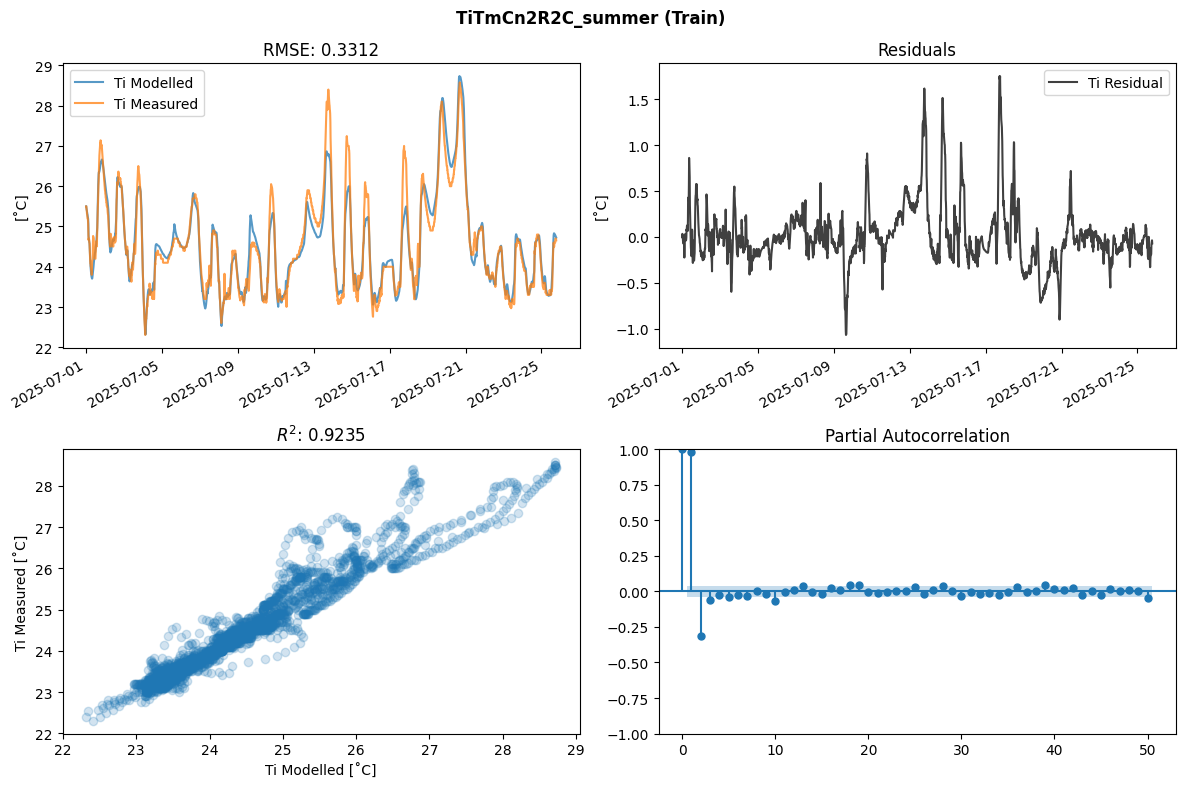

In [7]:
plot(y_train, train_results, 'TiTmCn2R2C_summer (Train)')

## Test results

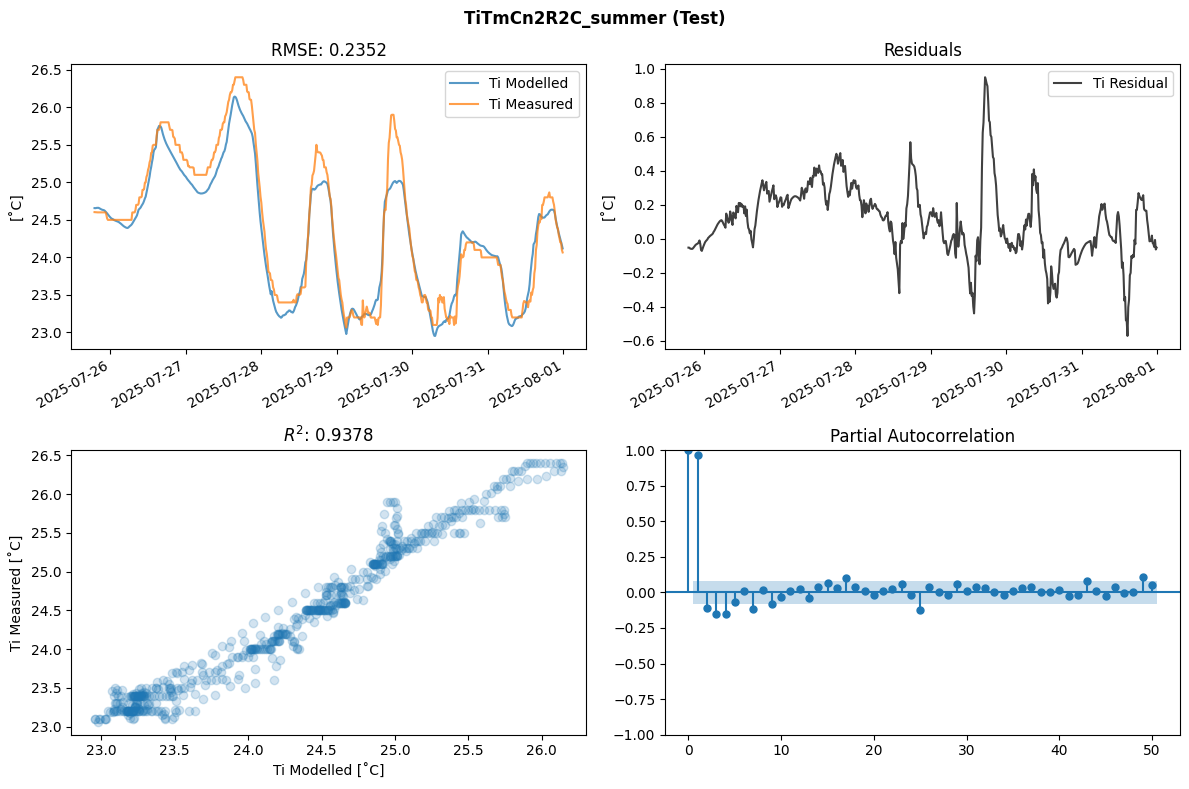

In [8]:
plot(y_test, test_results, 'TiTmCn2R2C_summer (Test)')

## Plot the main results

Using variables already in memory.


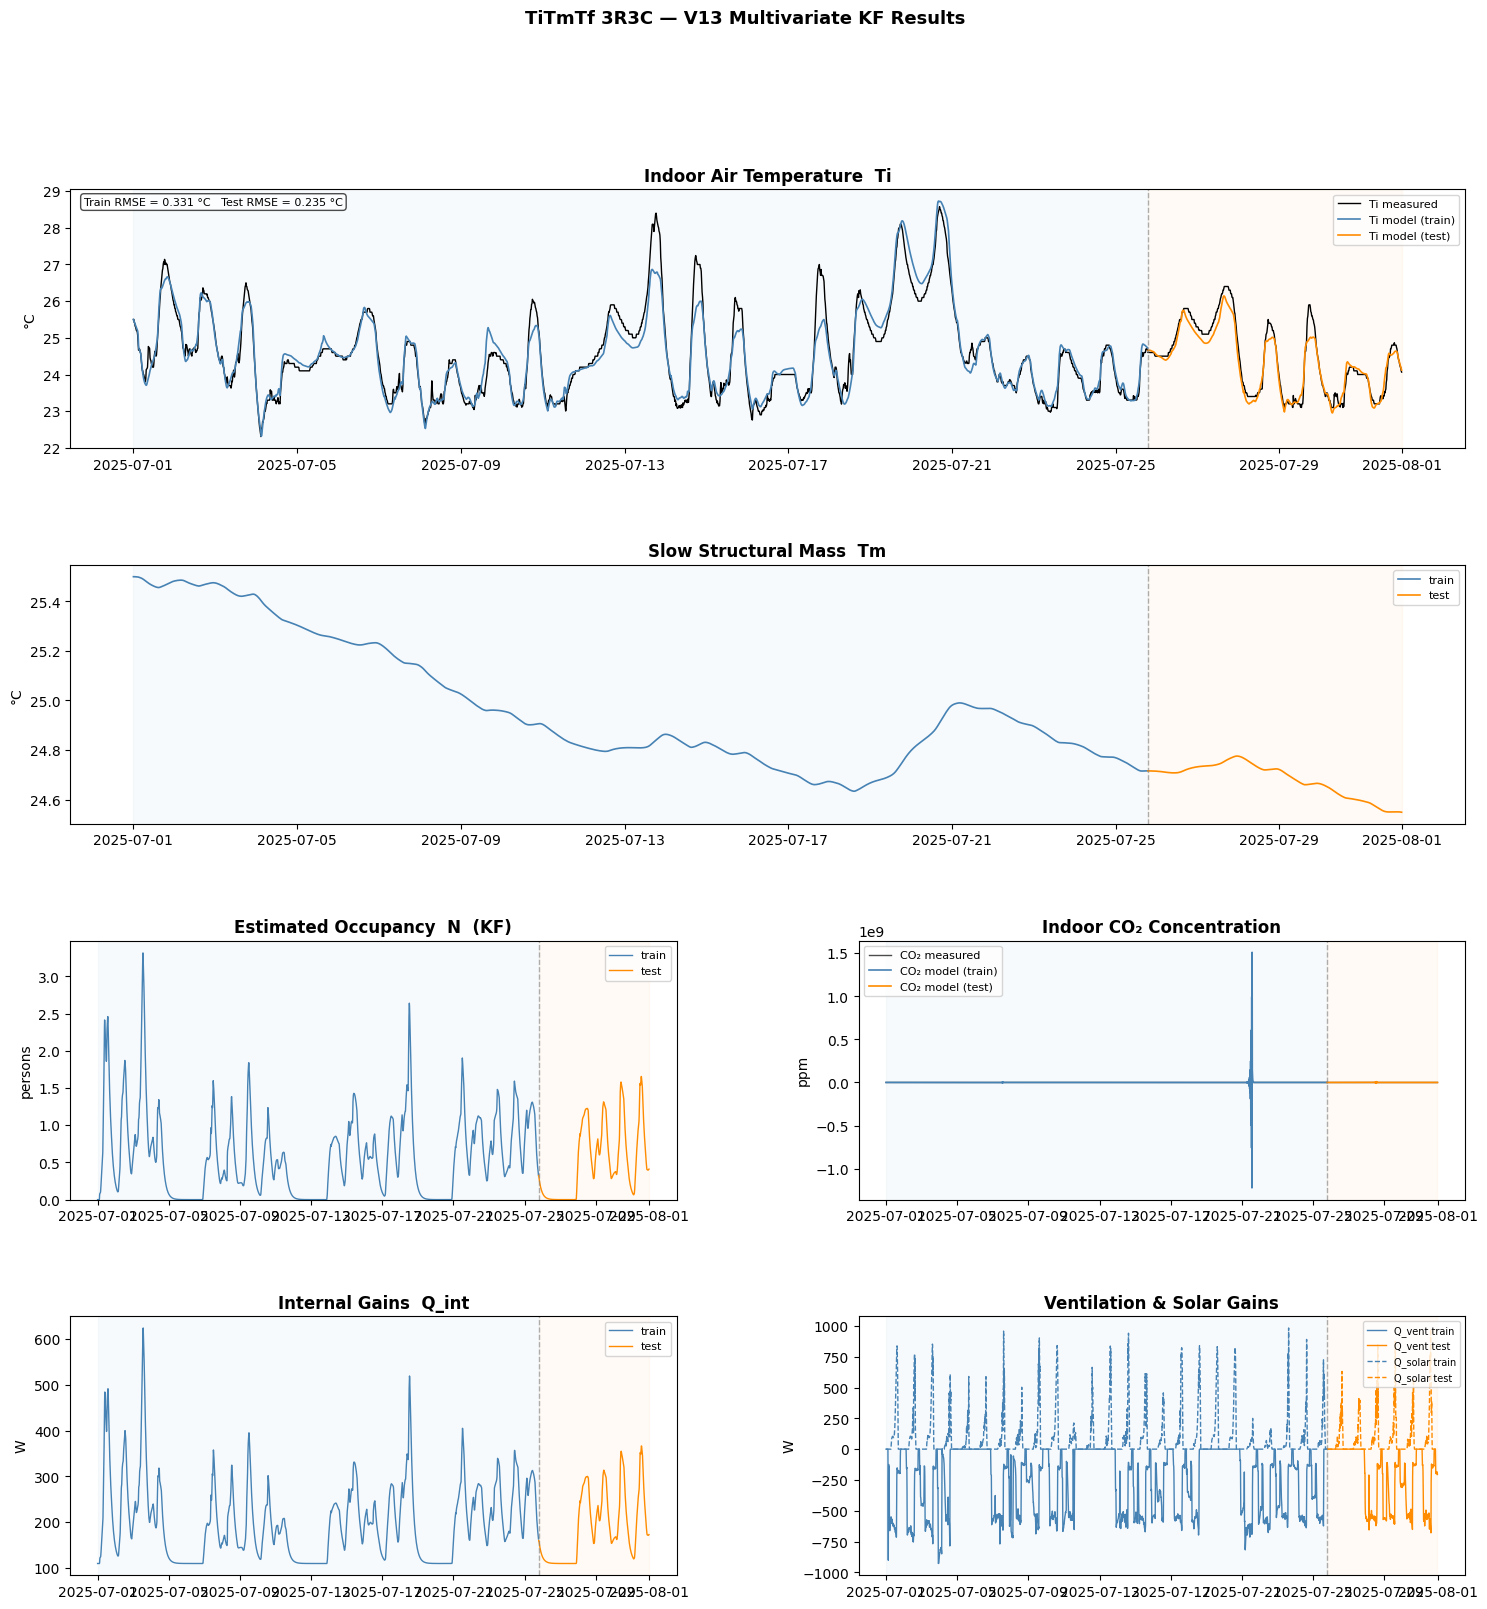

In [9]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

RESULTS_FILE = "simulation_results.pkl"

# ── Load from pickle if variables are not already in memory ──────────────────
if 'df' not in dir() or 'y_train' not in dir():
    print("Variables not in memory — loading from saved file...")
    with open(RESULTS_FILE, "rb") as f:
        saved = pickle.load(f)
    df            = saved["df"]
    X_train       = saved["X_train"]
    y_train       = saved["y_train"]
    X_test        = saved["X_test"]
    y_test        = saved["y_test"]
    model         = saved["model"]
    train_results = saved["train_results"]
    test_results  = saved["test_results"]
    print("Loaded successfully!")
else:
    print("Using variables already in memory.")

# ── get_var: handles DarkGreyModelResult attribute-based access ───────────────
def get_var(result, key):
    if key in result.var:
        return np.asarray(result.var[key], dtype=float)
    print(f"Warning: '{key}' not found in result.var. Available keys: {list(result.var.keys())}")
    return None

def rmse(pred, actual):
    return np.sqrt(np.mean((np.asarray(pred) - np.asarray(actual)) ** 2))

# ── Reconstruct time index ────────────────────────────────────────────────────
train_index = X_train.index
test_index  = X_test.index

# ── Unpack results ────────────────────────────────────────────────────────────
Ti_train   = get_var(train_results, 'Ti')
Tm_train   = get_var(train_results, 'Tm')
N_train    = get_var(train_results, 'N')
c_train    = get_var(train_results, 'c')
Qint_train = get_var(train_results, 'Q_int')
Qven_train = get_var(train_results, 'Q_vent')
Qsol_train = get_var(train_results, 'Q_solar')

Ti_test    = get_var(test_results, 'Ti')
Tm_test    = get_var(test_results, 'Tm')
N_test     = get_var(test_results, 'N')
c_test     = get_var(test_results, 'c')
Qint_test  = get_var(test_results, 'Q_int')
Qven_test  = get_var(test_results, 'Q_vent')
Qsol_test  = get_var(test_results, 'Q_solar')

c_meas_train = np.asarray(X_train['c'], dtype=float)
c_meas_test  = np.asarray(X_test['c'],  dtype=float)

# ── Figure layout — 4 rows ────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 18))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

ax_ti   = fig.add_subplot(gs[0, :])
ax_tm   = fig.add_subplot(gs[1, :])
ax_n    = fig.add_subplot(gs[2, 0])
ax_co2  = fig.add_subplot(gs[2, 1])
ax_qint = fig.add_subplot(gs[3, 0])
ax_qven = fig.add_subplot(gs[3, 1])

def shade_split(ax):
    ax.axvline(test_index[0], color='grey', lw=1, ls='--', alpha=0.6)
    ax.axvspan(train_index[0], test_index[0],  alpha=0.04, color='steelblue')
    ax.axvspan(test_index[0],  test_index[-1], alpha=0.04, color='darkorange')

# ── 1. Ti ─────────────────────────────────────────────────────────────────────
ax_ti.plot(train_index, y_train,  color='black',      lw=1.0, label='Ti measured')
ax_ti.plot(train_index, Ti_train, color='steelblue',  lw=1.2, label='Ti model (train)')
ax_ti.plot(test_index,  y_test,   color='black',      lw=1.0)
ax_ti.plot(test_index,  Ti_test,  color='darkorange', lw=1.2, label='Ti model (test)')
shade_split(ax_ti)
ax_ti.set_title('Indoor Air Temperature  Ti', fontweight='bold')
ax_ti.set_ylabel('°C')
ax_ti.legend(fontsize=8)
ax_ti.text(0.01, 0.97,
    f'Train RMSE = {rmse(Ti_train, y_train.values):.3f} °C   '
    f'Test RMSE = {rmse(Ti_test, y_test.values):.3f} °C',
    transform=ax_ti.transAxes, va='top', fontsize=8,
    bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# ── 2. Tm ─────────────────────────────────────────────────────────────────────
ax_tm.plot(train_index, Tm_train, color='steelblue',  lw=1.2, label='train')
ax_tm.plot(test_index,  Tm_test,  color='darkorange', lw=1.2, label='test')
shade_split(ax_tm)
ax_tm.set_title('Slow Structural Mass  Tm', fontweight='bold')
ax_tm.set_ylabel('°C')
ax_tm.legend(fontsize=8)

# ── 3. Occupancy N ────────────────────────────────────────────────────────────
ax_n.plot(train_index, N_train, color='steelblue',  lw=1.0, label='train')
ax_n.plot(test_index,  N_test,  color='darkorange', lw=1.0, label='test')
ax_n.set_ylim(bottom=0)
shade_split(ax_n)
ax_n.set_title('Estimated Occupancy  N  (KF)', fontweight='bold')
ax_n.set_ylabel('persons')
ax_n.legend(fontsize=8)

# ── 4. CO2 ────────────────────────────────────────────────────────────────────
ax_co2.plot(train_index, c_meas_train, color='black',      lw=1.0, alpha=0.7, label='CO₂ measured')
ax_co2.plot(train_index, c_train,      color='steelblue',  lw=1.2, label='CO₂ model (train)')
ax_co2.plot(test_index,  c_meas_test,  color='black',      lw=1.0, alpha=0.7)
ax_co2.plot(test_index,  c_test,       color='darkorange', lw=1.2, label='CO₂ model (test)')
shade_split(ax_co2)
ax_co2.set_title('Indoor CO₂ Concentration', fontweight='bold')
ax_co2.set_ylabel('ppm')
ax_co2.legend(fontsize=8)

# ── 5. Internal heat gains ────────────────────────────────────────────────────
ax_qint.plot(train_index, Qint_train, color='steelblue',  lw=1.0, label='train')
ax_qint.plot(test_index,  Qint_test,  color='darkorange', lw=1.0, label='test')
shade_split(ax_qint)
ax_qint.set_title('Internal Gains  Q_int', fontweight='bold')
ax_qint.set_ylabel('W')
ax_qint.legend(fontsize=8)

# ── 6. Ventilation + solar ────────────────────────────────────────────────────
ax_qven.plot(train_index, Qven_train, color='steelblue',  lw=1.0, label='Q_vent train')
ax_qven.plot(test_index,  Qven_test,  color='darkorange', lw=1.0, label='Q_vent test')
ax_qven.plot(train_index, Qsol_train, color='steelblue',  lw=1.0, ls='--', label='Q_solar train')
ax_qven.plot(test_index,  Qsol_test,  color='darkorange', lw=1.0, ls='--', label='Q_solar test')
shade_split(ax_qven)
ax_qven.set_title('Ventilation & Solar Gains', fontweight='bold')
ax_qven.set_ylabel('W')
ax_qven.legend(fontsize=7)

# ── Save & show ───────────────────────────────────────────────────────────────
fig.suptitle('TiTmTf 3R3C — V13 Multivariate KF Results',
             fontsize=13, fontweight='bold')
plt.savefig('V13_results.png', dpi=150, bbox_inches='tight')
plt.show()


# NIGHT VENTILATION

## Analysis of the existing behaviour

  EXISTING NIGHT VENTILATION ANALYSIS
  Night window           : 22:00 – 07:00
  qv threshold used      : 0.0 m³/h
  Night steps total      : 892
  Night vent active      : 606 steps  (67.9%)
  Free cooling active    : 606 steps  (67.9%)
  Missed opportunities   : 286 steps  (32.1%)
  Mean qv (night, active): 212.1 m³/h
  Max  qv (night)        : 285.3 m³/h
  Mean qv (daytime)      : 112.0 m³/h
  Mean ΔT when active    : 6.69 °C  (Ti − Ta)
  Mean ΔT missed opport. : 7.82 °C  (Ti − Ta)


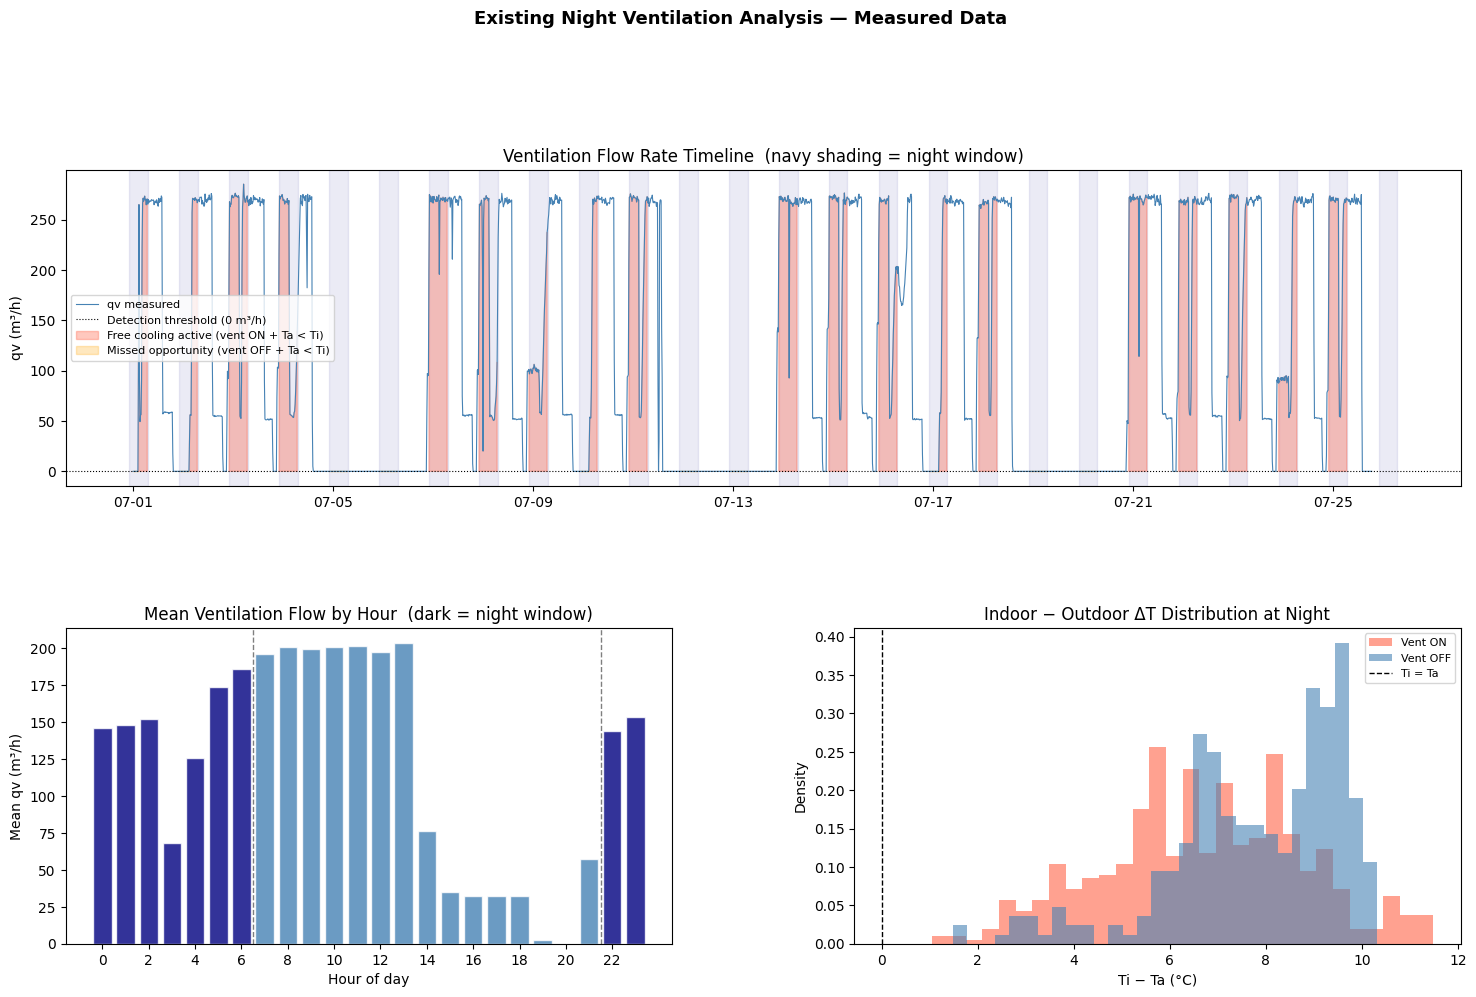

In [10]:
# ════════════════════════════════════════════════════════════════════════════
#  NIGHT VENTILATION ANALYSIS — existing behaviour in measured data
# ════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# ── Config ───────────────────────────────────────────────────────────────────
NIGHT_START   = 22      # hour (inclusive)
NIGHT_STOP    = 7       # hour (exclusive, crosses midnight)
QV_THRESHOLD  = float(np.percentile(np.asarray(X_train['qv'], dtype=float), 25))
                        # anything above 25th percentile at night = "ventilation active"

# ── Raw arrays ───────────────────────────────────────────────────────────────
index   = X_train.index
qv_arr  = np.asarray(X_train['qv'],  dtype=float)
Ta_arr  = np.asarray(X_train['Ta'],  dtype=float)
Ti_meas = np.asarray(y_train,        dtype=float)
hours   = np.array([t.hour + t.minute / 60.0 for t in index])
dt_h    = (index[1] - index[0]).seconds / 3600.0

# ── Night mask (crosses midnight) ────────────────────────────────────────────
night_mask = (hours >= NIGHT_START) | (hours < NIGHT_STOP)

# ── Detect night ventilation events ──────────────────────────────────────────
night_vent_active = night_mask & (qv_arr > QV_THRESHOLD)
free_cooling_ok   = night_mask & (qv_arr > QV_THRESHOLD) & (Ta_arr < Ti_meas)
free_cooling_miss = night_mask & (qv_arr <= QV_THRESHOLD) & (Ta_arr < Ti_meas)
                    # night, no vent, but outdoor is cooler → missed opportunity

# ── Summary statistics ────────────────────────────────────────────────────────
n_night_steps        = night_mask.sum()
n_vent_steps         = night_vent_active.sum()
n_free_cooling_steps = free_cooling_ok.sum()
n_missed_steps       = free_cooling_miss.sum()

pct_night_vented     = 100 * n_vent_steps / n_night_steps if n_night_steps > 0 else 0
pct_free_cooling     = 100 * n_free_cooling_steps / n_night_steps if n_night_steps > 0 else 0
pct_missed           = 100 * n_missed_steps / n_night_steps if n_night_steps > 0 else 0

qv_night_mean = qv_arr[night_vent_active].mean() if n_vent_steps > 0 else 0
qv_night_max  = qv_arr[night_vent_active].max()  if n_vent_steps > 0 else 0
qv_day_mean   = qv_arr[~night_mask].mean()

delta_T_free  = (Ti_meas - Ta_arr)[free_cooling_ok]   # Ti - Ta when free cooling active
delta_T_miss  = (Ti_meas - Ta_arr)[free_cooling_miss]  # Ti - Ta when opportunity missed

print("=" * 60)
print("  EXISTING NIGHT VENTILATION ANALYSIS")
print("=" * 60)
print(f"  Night window           : {NIGHT_START}:00 – {NIGHT_STOP:02d}:00")
print(f"  qv threshold used      : {QV_THRESHOLD:.1f} m³/h")
print(f"  Night steps total      : {n_night_steps}")
print(f"  Night vent active      : {n_vent_steps} steps  ({pct_night_vented:.1f}%)")
print(f"  Free cooling active    : {n_free_cooling_steps} steps  ({pct_free_cooling:.1f}%)")
print(f"  Missed opportunities   : {n_missed_steps} steps  ({pct_missed:.1f}%)")
print(f"  Mean qv (night, active): {qv_night_mean:.1f} m³/h")
print(f"  Max  qv (night)        : {qv_night_max:.1f} m³/h")
print(f"  Mean qv (daytime)      : {qv_day_mean:.1f} m³/h")
if len(delta_T_free) > 0:
    print(f"  Mean ΔT when active    : {delta_T_free.mean():.2f} °C  (Ti − Ta)")
if len(delta_T_miss) > 0:
    print(f"  Mean ΔT missed opport. : {delta_T_miss.mean():.2f} °C  (Ti − Ta)")
print("=" * 60)

# ── Hourly profile: mean qv by hour ──────────────────────────────────────────
hour_int   = np.array([t.hour for t in index])
qv_by_hour = np.array([qv_arr[hour_int == h].mean() for h in range(24)])

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 16))
gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])   # full width — qv timeline
ax2 = fig.add_subplot(gs[1, 0])   # hourly qv profile
ax3 = fig.add_subplot(gs[1, 1])   # ΔT histogram (Ti - Ta) during night

fig.suptitle('Existing Night Ventilation Analysis — Measured Data', fontsize=13, fontweight='bold')

# ── 1. qv timeline with night shading ────────────────────────────────────────
ax1.plot(index, qv_arr, color='steelblue', lw=0.8, label='qv measured')
ax1.axhline(QV_THRESHOLD, color='black', lw=0.8, ls=':', label=f'Detection threshold ({QV_THRESHOLD:.0f} m³/h)')

# shade night periods
day_start = index[0].normalize()
for d in range((index[-1] - index[0]).days + 2):
    ns = day_start + pd.Timedelta(hours=NIGHT_START + d * 24 - 24)
    ne = day_start + pd.Timedelta(hours=NIGHT_STOP   + d * 24)
    ax1.axvspan(ns, ne, alpha=0.08, color='navy', zorder=0)

# mark free-cooling active steps
ax1.fill_between(index, qv_arr, 0,
    where=free_cooling_ok, alpha=0.35, color='tomato',
    label='Free cooling active (vent ON + Ta < Ti)')
ax1.fill_between(index, QV_THRESHOLD, 0,
    where=free_cooling_miss, alpha=0.25, color='orange',
    label='Missed opportunity (vent OFF + Ta < Ti)')

ax1.set_ylabel('qv (m³/h)')
ax1.legend(fontsize=8)
ax1.set_title('Ventilation Flow Rate Timeline  (navy shading = night window)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# ── 2. Mean qv by hour of day ─────────────────────────────────────────────────
bar_colors = ['navy' if (h >= NIGHT_START or h < NIGHT_STOP) else 'steelblue'
              for h in range(24)]
ax2.bar(range(24), qv_by_hour, color=bar_colors, alpha=0.8, edgecolor='white')
ax2.axvline(NIGHT_START - 0.5, color='black', lw=1, ls='--', alpha=0.5)
ax2.axvline(NIGHT_STOP  - 0.5, color='black', lw=1, ls='--', alpha=0.5)
ax2.set_xlabel('Hour of day')
ax2.set_ylabel('Mean qv (m³/h)')
ax2.set_title('Mean Ventilation Flow by Hour  (dark = night window)')
ax2.set_xticks(range(0, 24, 2))

# ── 3. Histogram of ΔT = Ti − Ta during night ─────────────────────────────────
delta_T_all_night = (Ti_meas - Ta_arr)[night_mask]
ax3.hist(delta_T_all_night[night_vent_active[night_mask]],
         bins=30, color='tomato', alpha=0.6, label='Vent ON', density=True)
ax3.hist(delta_T_all_night[~night_vent_active[night_mask]],
         bins=30, color='steelblue', alpha=0.6, label='Vent OFF', density=True)
ax3.axvline(0, color='black', lw=1, ls='--', label='Ti = Ta')
ax3.set_xlabel('Ti − Ta (°C)')
ax3.set_ylabel('Density')
ax3.set_title('Indoor − Outdoor ΔT Distribution at Night')
ax3.legend(fontsize=8)


plt.savefig('night_vent_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## Setup

In [11]:
# ════════════════════════════════════════════════════════════════════════════
#  SETUP — Shared parameters, constants, and initial conditions
#  Run this cell once before any scenario / analysis / optimisation block
# ════════════════════════════════════════════════════════════════════════════

# ── Model fitted parameters ───────────────────────────────────────────────────
fitted_params = model.result.params          # lmfit / statsmodels params object

# ── Time index (derived from training data) ───────────────────────────────────
index   = X_train.index                      # DatetimeIndex shared by all blocks
dt_h    = (index[1] - index[0]).seconds / 3600.0   # timestep in hours

# ── Initial conditions (taken from the first training step) ───────────────────
Ti_init = float(y_train.iloc[0])             # Indoor air temperature  [°C]
Tm_init = float(train_results.var['Tm'][0])  # Thermal mass temperature [°C]
c_init  = float(train_results.var['c'][0])   # CO₂ concentration        [ppm]
N_hist  = train_results.var['N']             # Estimated occupancy series

# ── Ventilation flow bounds ───────────────────────────────────────────────────
QV_MIN  = 0.0      # m³/h — lower bound (fan off)
QV_MAX = 270.0    # m³/h — your room valve max (confirmed)

# ── Energy cost parameters ────────────────────────────────────────────────────
# SFPv from datasheet: 1.84 kW/(m³/s) = 1840/3600 W/(m³/h)
# Proportionally attributed to this room (270/35000 = 0.77% of AHU)
SFP = 1840 / 3600   # = 0.511 W/(m³/h)
P_ELEC  = 1.493    # DKK/kWh  — Danish commercial all-in tariff, DK2 zone

# ── Quick sanity check ────────────────────────────────────────────────────────
print(f"Index range   : {index[0]}  →  {index[-1]}")
print(f"Timestep      : {dt_h:.4f} h  ({dt_h*60:.1f} min)")
print(f"Ti_init       : {Ti_init:.2f} °C")
print(f"Tm_init       : {Tm_init:.2f} °C")
print(f"c_init        : {c_init:.1f} ppm")
print(f"QV bounds     : [{QV_MIN}, {QV_MAX}] m³/h")
print(f"SFP / P_ELEC  : {SFP} W/(m³/h)  /  {P_ELEC} DKK/kWh")

Index range   : 2025-07-01 00:00:00+00:00  →  2025-07-25 18:45:00+00:00
Timestep      : 0.2500 h  (15.0 min)
Ti_init       : 25.50 °C
Tm_init       : 25.50 °C
c_init        : 430.9 ppm
QV bounds     : [0.0, 270.0] m³/h
SFP / P_ELEC  : 0.5111111111111111 W/(m³/h)  /  1.493 DKK/kWh


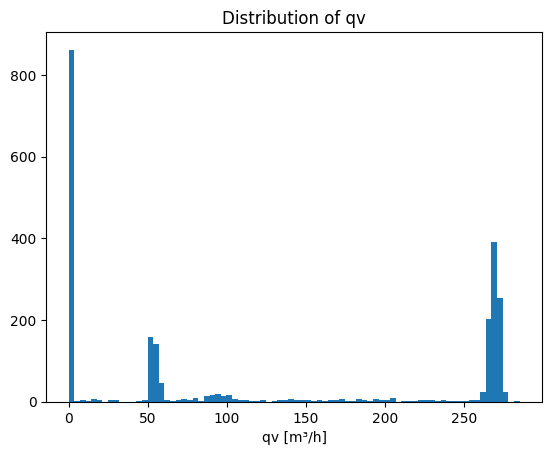

In [12]:
import matplotlib.pyplot as plt
import numpy as np

qv = np.asarray(X_train['qv'])
plt.hist(qv, bins=80)
plt.xlabel('qv [m³/h]')
plt.title('Distribution of qv')
plt.show()

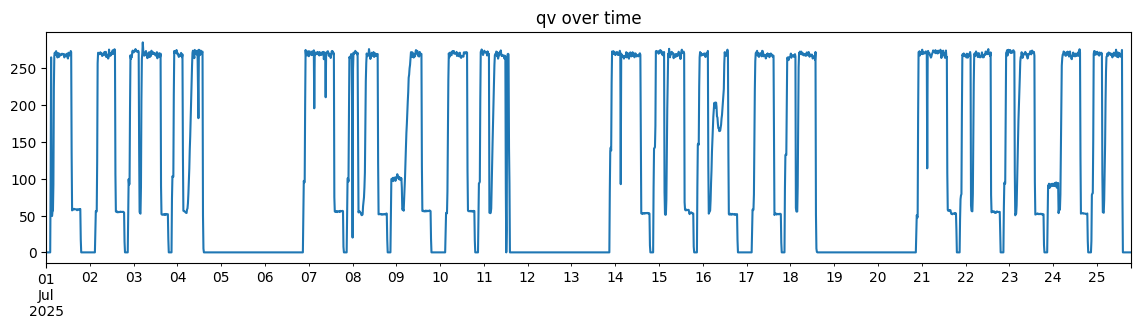

In [13]:
pd.Series(qv, index=index).plot(figsize=(14,3))
plt.title('qv over time')
plt.show()

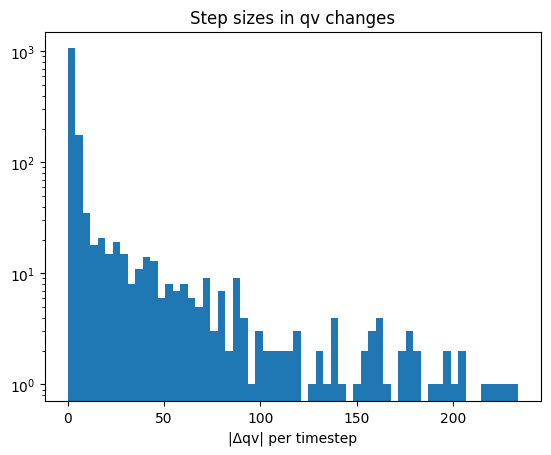

In [14]:
dqv = np.abs(np.diff(qv))
plt.hist(dqv[dqv > 0], bins=60, log=True)
plt.xlabel('|Δqv| per timestep')
plt.title('Step sizes in qv changes')
plt.show()

## Pre computation block

In [15]:
# ════════════════════════════════════════════════════════════════════════════
#  PRE-COMPUTATION  —  ANN Surrogate + NSGA-II  (stripped to essentials)
# ════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── CONFIG ───────────────────────────────────────────────────────────────────
T_cat1_min        = 22.0
T_cat1_max        = 24.0
T_TARGET          = 23.0
TA_MIN_NIGHT_VENT = 14.0
OCC_START         = 8
OCC_END           = 18
dt_h              = rec_duration

# ── UNIFIED BOUNDS — restored to match old Pareto sweep ──────────────────────
# FIX 1: START_LB = 15h (was 20h — was cutting off pre-cooling window)
# FIX 2: STOP_UB  = 10h (was  7h — was cutting off late morning hours)
NIGHT_OPT_START_LB = 20.0   # no earlier than 20:00
NIGHT_OPT_START_UB = 23.0
NIGHT_OPT_STOP_LB  =  2.0   # no earlier than 02:00 — forces at least some night
NIGHT_OPT_STOP_UB  =  8.0   # no later than 08:00

NIGHT_START = 20
NIGHT_STOP  =  8

# ── PHYSICAL CONSTANTS ───────────────────────────────────────────────────────
RHO_AIR  = 1.2
CP_AIR   = 1005.0
COP_COOL = 3.0

_SFP_REF = SFP
_QV_REF  = QV_MAX

# ── AIVC COST FUNCTIONS ──────────────────────────────────────────────────────
def sfp_aivc(qv_array):
    qv = np.asarray(qv_array, dtype=float)
    return np.where(qv > 0.0, _SFP_REF * (qv / _QV_REF) ** 2, 0.0)

def fan_cost_aivc(qv_array):
    qv   = np.asarray(qv_array, dtype=float)
    P_kW = qv / 3.6 * sfp_aivc(qv) / 1000.0
    return float(np.sum(P_kW) * P_ELEC * dt_h)

def q_cool_cost(qv_array, T_ext_arr, T_sup_arr):
    qv    = np.asarray(qv_array,  dtype=float)
    T_ext = np.asarray(T_ext_arr, dtype=float)
    T_sup = np.asarray(T_sup_arr, dtype=float)
    delta = np.maximum(0.0, T_ext - T_sup)
    Q_kW  = (qv / 3600.0) * RHO_AIR * CP_AIR * delta / 1000.0
    return float(np.sum(Q_kW) * dt_h / COP_COOL * P_ELEC)

def total_system_cost(qv_array, T_ext_arr, T_sup_arr):
    return fan_cost_aivc(qv_array) + q_cool_cost(qv_array, T_ext_arr, T_sup_arr)

# ── TIME / MASK ARRAYS ───────────────────────────────────────────────────────
hours    = np.array([t.hour + t.minute / 60.0 for t in index])
weekdays = np.array([t.weekday() for t in index])
Ta_arr   = np.asarray(X_train['Ta'], dtype=float)
qv_arr   = np.asarray(X_train['qv'], dtype=float)

occ_mask = (hours >= OCC_START) & (hours < OCC_END)
weekday_day_mask = occ_mask & (weekdays < 5)

# Night mask spans 15h–10h outer envelope (wraps midnight)
nighttime_mask = (hours >= NIGHT_START) | (hours < NIGHT_STOP)

def _next_morning_is_weekday(t):
    ref = t + pd.Timedelta(days=1) if t.hour >= NIGHT_START else t
    return ref.weekday() < 5

weekday_night_mask = nighttime_mask & np.array(
    [_next_morning_is_weekday(t) for t in index])
all_night_mask     = nighttime_mask.copy()

# Condensation check — kept for diagnostics/reference, NOT used in build_X_monthly
ta_ok_mask = Ta_arr > TA_MIN_NIGHT_VENT

# ── HELPER FUNCTIONS ─────────────────────────────────────────────────────────
def pct_in_band(Ti_series, Tmin, Tmax, mask):
    Ti = np.asarray(Ti_series)[mask]
    return float(np.mean((Ti >= Tmin) & (Ti <= Tmax)) * 100)

def dh_from_target(Ti_arr, T_target=T_TARGET, mask=None):
    Ti = np.asarray(Ti_arr)
    if mask is not None:
        Ti = Ti[mask]
    dh_above = float(np.sum(np.maximum(0.0, Ti - T_target)) * dt_h)
    dh_below = float(np.sum(np.maximum(0.0, T_target - Ti)) * dt_h)
    return dh_above, dh_below

# ── MONTH LAYOUT ─────────────────────────────────────────────────────────────
months_in_data = pd.DatetimeIndex(index).to_period('M').unique()
N_months       = len(months_in_data)
month_labels   = [str(m) for m in months_in_data]
month_periods  = np.array([t.to_period('M') for t in index])

MONTHLY_BOUNDS = (
    [(NIGHT_OPT_START_LB, NIGHT_OPT_START_UB),
     (NIGHT_OPT_STOP_LB,  NIGHT_OPT_STOP_UB),
     (QV_MIN,             QV_MAX             )] * N_months
)

print(f"Months: {month_labels}  →  {N_months * 3} optimisation variables")

def _wday_check_fn(t, h_start):
    ref = t + pd.Timedelta(days=1) if t.hour >= h_start else t
    return ref.weekday() < 5

# ── BUILD_X_MONTHLY — FIX 3: ta_ok_mask REMOVED ──────────────────────────────
# The mask was filtering out warm afternoon hours (15–19h), making start_h
# irrelevant to the optimizer → Pareto front collapsed.
# q_cool_cost() already penalises T_ext > T_sup — no pre-filtering needed.
def build_X_monthly(params):
    params   = np.asarray(params, dtype=float)
    qv_mod   = np.asarray(X_train['qv'],   dtype=float).copy()
    Tsup_mod = np.asarray(X_train['Tsup'], dtype=float).copy()

    for i, month in enumerate(months_in_data):
        h_start = float(np.clip(params[3*i],     NIGHT_OPT_START_LB, NIGHT_OPT_START_UB))
        h_stop  = float(np.clip(params[3*i + 1], NIGHT_OPT_STOP_LB,  NIGHT_OPT_STOP_UB))
        qv_val  = float(np.clip(params[3*i + 2], QV_MIN,             QV_MAX))

        month_m = (month_periods == month)

        if h_start > h_stop:   # window wraps midnight
            night_m = (hours >= h_start) | (hours < h_stop)
        else:
            night_m = (hours >= h_start) & (hours < h_stop)

        wday_ok = np.array([_wday_check_fn(t, h_start) for t in index])
        mask_n  = month_m & night_m & wday_ok

        # Apply to ALL eligible hours — no ta_ok_mask suppression
        # Warm-hour ventilation is penalised naturally via q_cool_cost()
        qv_mod[mask_n]   = qv_val
        Tsup_mod[mask_n] = Ta_arr[mask_n]

    return qv_mod, Tsup_mod

# ── SCENARIO 1 — BASE SIMULATION ─────────────────────────────────────────────
print("Running Scenario 1 — base simulation...")
base_sim_result = simulate_night_vent_scenario(
    fitted_params, X_train, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

Ti_ref        = np.asarray(base_sim_result['Ti'])
Tsup_ref      = np.asarray(X_train['Tsup'], dtype=float)
cost_ref      = total_system_cost(qv_arr, Ta_arr, Tsup_ref)
pct_occ_ref   = pct_in_band(Ti_ref, T_cat1_min, T_cat1_max, occ_mask)
pct_night_ref = pct_in_band(Ti_ref, T_cat1_min, T_cat1_max, all_night_mask)
dh_above_ref, dh_below_ref = dh_from_target(Ti_ref)
print(f"  Base sim:  {dh_above_ref:.1f} °C·h  |  {cost_ref:.2f} DKK  |  {pct_occ_ref:.1f}% day")

# ── SCENARIO 3 — BASELINE (no night ventilation) ──────────────────────────────
print("Running Scenario 3 — baseline (no night vent)...")
qv_baseline      = qv_arr.copy()
qv_baseline[weekday_night_mask] = 0.0

X_base       = X_train.copy()
X_base['qv'] = qv_baseline

baseline = simulate_night_vent_scenario(
    fitted_params, X_base, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

Ti_baseline                  = np.asarray(baseline['Ti'])
Tsup_base                    = np.asarray(X_base['Tsup'], dtype=float)
cost_baseline                = total_system_cost(qv_baseline, Ta_arr, Tsup_base)
pct_occ_base                 = pct_in_band(Ti_baseline, T_cat1_min, T_cat1_max, occ_mask)
dh_above_base, dh_below_base = dh_from_target(Ti_baseline)
print(f"  Baseline:  {dh_above_base:.1f} °C·h  |  {cost_baseline:.2f} DKK  |  {pct_occ_base:.1f}% day")

# ── DIAGNOSTIC: verify build_X_monthly now responds to start_h ───────────────
_p15 = np.array([15.0, 10.0, QV_MAX])
_p23 = np.array([23.0,  7.0, QV_MAX])
_qv15, _ts15 = build_X_monthly(_p15)
_qv23, _ts23 = build_X_monthly(_p23)
_base_qv = X_train['qv'].values
print(f"\n  Diagnostic — hours modified vs baseline qv:")
print(f"  start=15h, stop=10h: {int(np.sum(_qv15 != _base_qv))} hours  "
      f"cost={total_system_cost(_qv15, Ta_arr, _ts15):.2f} DKK")
print(f"  start=23h, stop= 7h: {int(np.sum(_qv23 != _base_qv))} hours  "
      f"cost={total_system_cost(_qv23, Ta_arr, _ts23):.2f} DKK")
print(f"  ✓ Cost difference = "
      f"{total_system_cost(_qv15, Ta_arr, _ts15) - total_system_cost(_qv23, Ta_arr, _ts23):+.2f} DKK  "
      f"(should be positive — early start costs more)")

print(f"\n  Pre-computation complete. Ready for ANN+NSGA-II.")

C:\Users\clemr\AppData\Local\Temp\ipykernel_18332\912398058.py:94: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  months_in_data = pd.DatetimeIndex(index).to_period('M').unique()
C:\Users\clemr\AppData\Local\Temp\ipykernel_18332\912398058.py:97: UserWarning: Converting to Period representation will drop timezone information.
  month_periods  = np.array([t.to_period('M') for t in index])


Months: ['2025-07']  →  3 optimisation variables
Running Scenario 1 — base simulation...
  Base sim:  922.1 °C·h  |  42.67 DKK  |  40.6% day
Running Scenario 3 — baseline (no night vent)...
  Baseline:  1080.0 °C·h  |  29.80 DKK  |  34.8% day

  Diagnostic — hours modified vs baseline qv:
  start=15h, stop=10h: 896 hours  cost=42.62 DKK
  start=23h, stop= 7h: 604 hours  cost=42.08 DKK
  ✓ Cost difference = +0.54 DKK  (should be positive — early start costs more)

  Pre-computation complete. Ready for ANN+NSGA-II.


## Night ventilation multi objective optimization


════════════════════════════════════════════════════════════════════════
  PHASE 1 — Latin Hypercube Sampling  (1000 points × 4 variables)
  start_h ∈ [20, 23]h  |  stop_h ∈ [2, 8]h  |  qv ∈ [0, 270] m³/h
════════════════════════════════════════════════════════════════════════
  Simulating sample 100/1000  (failed so far: 0)
  Simulating sample 200/1000  (failed so far: 0)
  Simulating sample 300/1000  (failed so far: 0)
  Simulating sample 400/1000  (failed so far: 0)
  Simulating sample 500/1000  (failed so far: 0)
  Simulating sample 600/1000  (failed so far: 0)
  Simulating sample 700/1000  (failed so far: 0)
  Simulating sample 800/1000  (failed so far: 0)
  Simulating sample 900/1000  (failed so far: 0)
  Simulating sample 1000/1000  (failed so far: 0)

  Sampling complete — 1000/1000 valid simulations
  °C·h  — min: 837.8  mean: 934.9  max: 1075.7
  cost  — min: 29.80  mean: 38.07  max: 45.68
  Saved: ann_lhs_training_data.csv

══════════════════════════════════════════════════

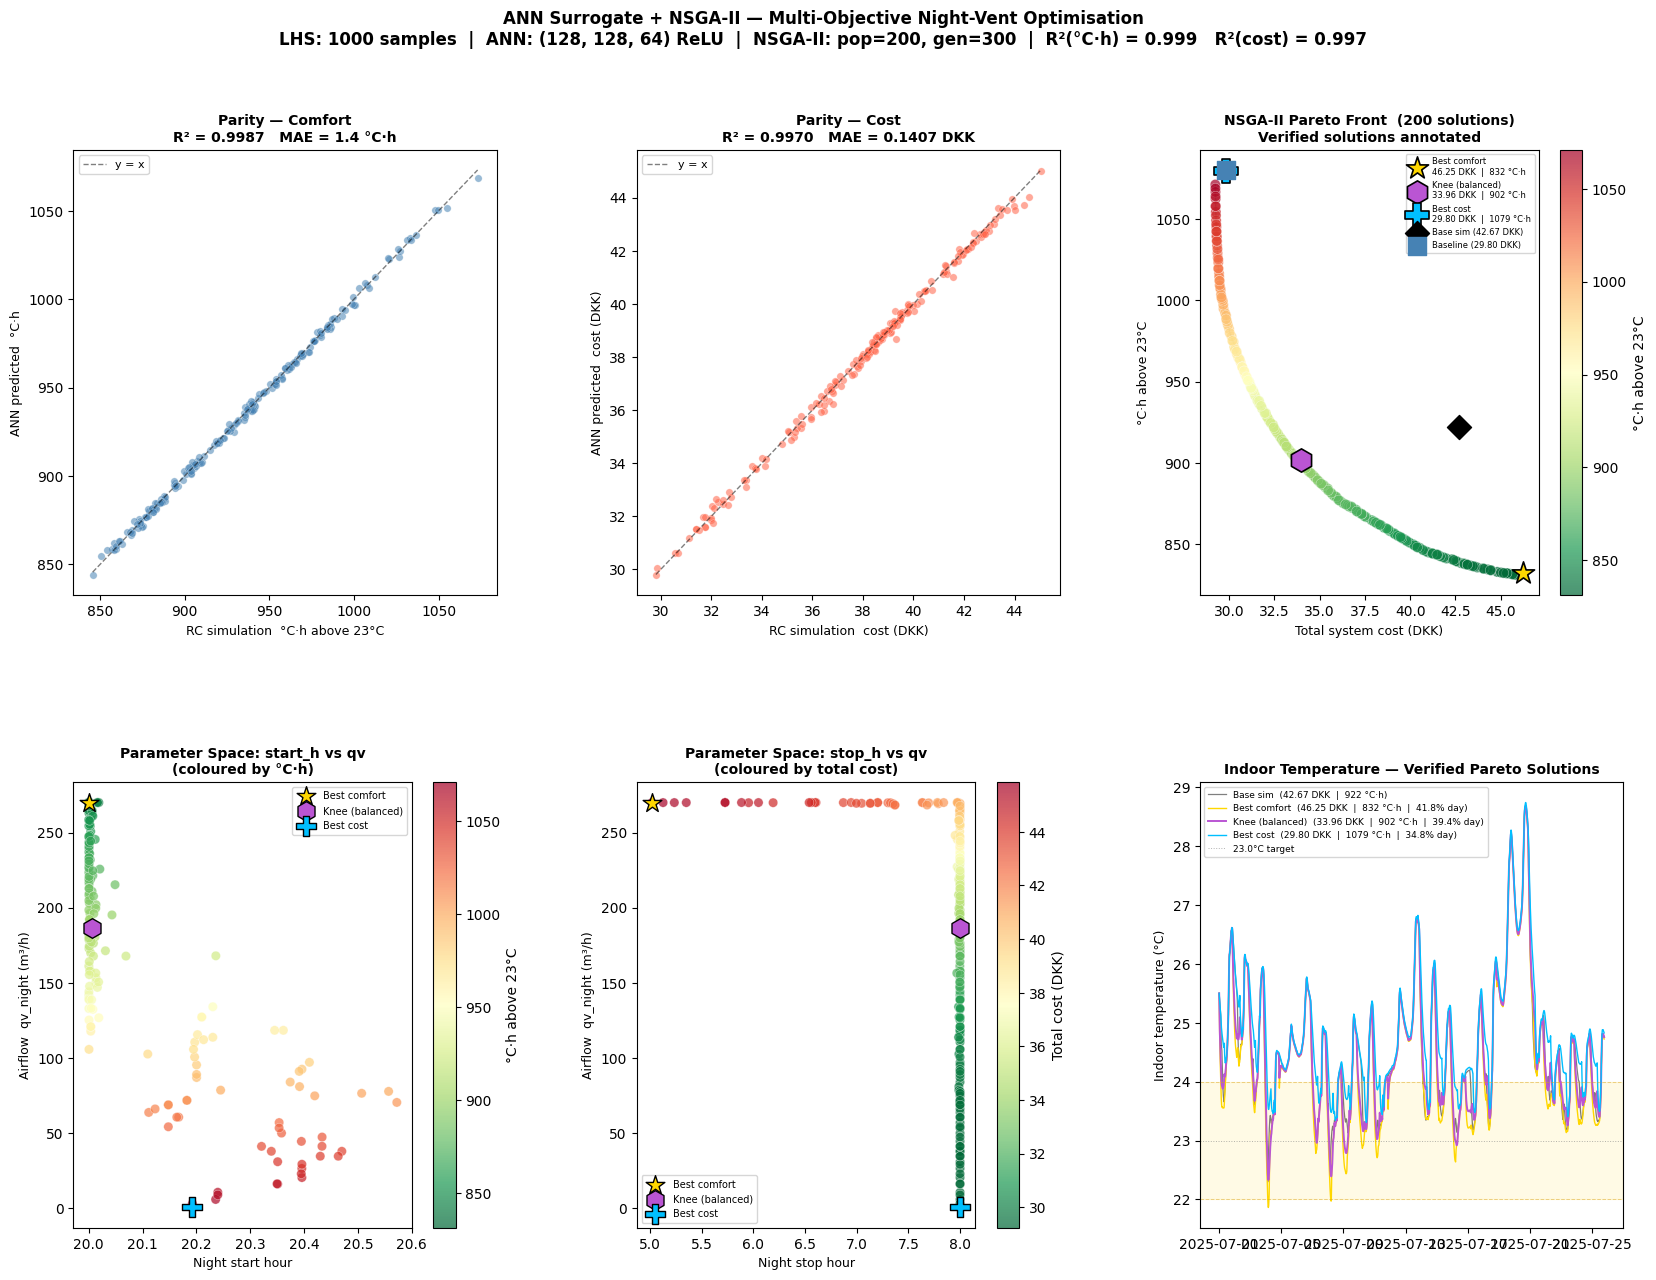


════════════════════════════════════════════════════════════════════════
  ANN + NSGA-II — RECOMMENDED SCHEDULE  (Pareto knee)
════════════════════════════════════════════════════════════════════════
  Night start   : 20.0h  →  20:00
  Night stop    : 8.0h  →  07:59
  Airflow       : 187 m³/h
  °C·h above 23°C: 901.5  (base sim: 922.1   Δ = -20.6)
  Day comfort   : 39.4%  (base sim: 40.6%)
  Total cost    : 33.96 DKK  (base sim: 42.67   Δ = -8.72)

────────────────────────────────────────────────────────────────────────
  Label                    Start   Stop     qv      °C·h       DKK     Day%    Night%
────────────────────────────────────────────────────────────────────────
  Best comfort            20.0h   5.0h   270     832.1     46.25    41.8%     49.1%
  Knee (balanced)         20.0h   8.0h   187     901.5     33.96    39.4%     41.5%
  Best cost               20.2h   8.0h     1    1079.5     29.80    34.8%     10.1%
──────────────────────────────────────────────────────────────

In [16]:
# ════════════════════════════════════════════════════════════════════════════
#  ANN SURROGATE + NSGA-II  —  Night-Vent Multi-Objective Optimisation
#
#  Pipeline:
#    Phase 1 — Latin Hypercube Sampling  →  RC simulation  →  training dataset
#    Phase 2 — Train & validate MLPRegressor surrogate  (128-128-64 ReLU)
#    Phase 3 — NSGA-II multi-objective optimisation on surrogate
#    Phase 4 — Re-simulate 3 key Pareto solutions with true RC model
#    Phase 5 — Dashboard figure + final schedule recommendation
#
#  Prerequisites (must already exist in namespace):
#    build_X_monthly, simulate_night_vent_scenario, total_system_cost,
#    dh_from_target, pct_in_band, fan_cost_aivc, q_cool_cost
#    fitted_params, X_train, N_hist, rec_duration, Ti_init, Tm_init, c_init
#    Ta_arr, qv_arr, index, occ_mask, all_night_mask, dt_h
#    T_TARGET, T_cat1_min, T_cat1_max, QV_MIN, QV_MAX
#    NIGHT_OPT_START_LB/UB, NIGHT_OPT_STOP_LB/UB     (unified bounds block)
#    dh_above_ref, cost_ref, pct_occ_ref, pct_night_ref   (Scenario 1)
#    dh_above_base, cost_baseline, pct_occ_base             (Scenario 3)
#    Ti_ref                                                  (Scenario 1)
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats.qmc import LatinHypercube, scale as lhs_scale
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize as pymoo_minimize
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.termination import get_termination


# ── TUNABLE ──────────────────────────────────────────────────────────────────
N_SAMPLES    = 1000
TEST_FRAC    = 0.20
ANN_LAYERS   = (128, 128, 64)
NSGA_POP     = 200
NSGA_GEN     = 300
RANDOM_SEED  = 42

N_VARS = 4   # ← add this — single source of truth for variable count

# ── PARAMETER BOUNDS ─────────────────────────────────────────────────────────
LB = np.array([NIGHT_OPT_START_LB, NIGHT_OPT_STOP_LB, QV_MIN, 0.0] * N_months)
UB = np.array([NIGHT_OPT_START_UB, NIGHT_OPT_STOP_UB, QV_MAX, 1.0] * N_months)
PARAM_NAMES = ['start_h', 'stop_h', 'qv_night', 'on_off']

# ── PHASE 1 — LHS sampling ───────────────────────────────────────────────────
print(f"\n{'═'*72}")
print(f"  PHASE 1 — Latin Hypercube Sampling  ({N_SAMPLES} points × {N_VARS} variables)")
print(f"  start_h ∈ [{LB[0]:.0f}, {UB[0]:.0f}]h  |  "
      f"stop_h ∈ [{LB[1]:.0f}, {UB[1]:.0f}]h  |  "
      f"qv ∈ [{LB[2]:.0f}, {UB[2]:.0f}] m³/h")
print(f"{'═'*72}")

sampler = LatinHypercube(d=N_VARS, seed=RANDOM_SEED)   # ← was d=3, now d=4
X_lhs   = lhs_scale(sampler.random(n=N_SAMPLES), LB, UB)

Y_dh   = np.zeros(N_SAMPLES)   # °C·h above T_TARGET
Y_cost = np.zeros(N_SAMPLES)   # total system cost [DKK]
_failed = 0

for i, params in enumerate(X_lhs):
    if (i + 1) % 100 == 0:
        print(f"  Simulating sample {i+1}/{N_SAMPLES}  "
              f"(failed so far: {_failed})")
    try:
        qv_mod, Tsup_mod = build_X_monthly(params)
        X_mod         = X_train.copy()
        X_mod['qv']   = qv_mod
        X_mod['Tsup'] = Tsup_mod
        res = simulate_night_vent_scenario(
            fitted_params, X_mod, N_hist,
            night_start_hour=0, night_stop_hour=0, qv_night=0,
            rec_duration=rec_duration,
            Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)
        Ti = np.asarray(res['Ti'])
        if np.all(np.isfinite(Ti)):
            Y_dh[i]   = float(np.sum(np.maximum(0.0, Ti - T_TARGET)) * dt_h)
            Y_cost[i] = total_system_cost(qv_mod, Ta_arr, Tsup_mod)
        else:
            # Invalid simulation — use penalised value so ANN avoids this region
            Y_dh[i]   = dh_above_ref * 2.0
            Y_cost[i] = cost_ref     * 2.0
            _failed  += 1
    except Exception as e:
        Y_dh[i]   = dh_above_ref * 2.0
        Y_cost[i] = cost_ref     * 2.0
        _failed  += 1

Y_lhs = np.column_stack([Y_dh, Y_cost])

print(f"\n  Sampling complete — {N_SAMPLES - _failed}/{N_SAMPLES} valid simulations")
print(f"  °C·h  — min: {Y_dh.min():.1f}  mean: {Y_dh.mean():.1f}  max: {Y_dh.max():.1f}")
print(f"  cost  — min: {Y_cost.min():.2f}  mean: {Y_cost.mean():.2f}  max: {Y_cost.max():.2f}")

# Save training dataset
_lhs_df = pd.DataFrame(
    np.column_stack([X_lhs, Y_lhs]),
    columns=['start_h', 'stop_h', 'qv_night', 'on_off', 'dh_above', 'cost_dkk'])
_lhs_df.to_csv('ann_lhs_training_data.csv', index=False)
print(f"  Saved: ann_lhs_training_data.csv")


# ════════════════════════════════════════════════════════════════════════════
#  PHASE 2 — Train & validate ANN surrogate
# ════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*72}")
print(f"  PHASE 2 — ANN surrogate  ({ANN_LAYERS} hidden units, ReLU, Adam)")
print(f"{'═'*72}")

# Train / test split
X_tr, X_te, Y_tr, Y_te = train_test_split(
    X_lhs, Y_lhs, test_size=TEST_FRAC, random_state=RANDOM_SEED)

# StandardScaler — fit on train only
scaler_X = StandardScaler().fit(X_tr)
scaler_Y = StandardScaler().fit(Y_tr)
X_tr_s   = scaler_X.transform(X_tr)
X_te_s   = scaler_X.transform(X_te)
Y_tr_s   = scaler_Y.transform(Y_tr)

# ANN — multi-output regression (both objectives simultaneously)
ann = MLPRegressor(
    hidden_layer_sizes=ANN_LAYERS,
    activation='relu',
    solver='adam',
    alpha=1e-4,              # L2 regularisation
    max_iter=3000,
    learning_rate_init=1e-3,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=60,
    random_state=RANDOM_SEED,
    verbose=False
)
ann.fit(X_tr_s, Y_tr_s)
print(f"  Training stopped at iteration {ann.n_iter_} / {ann.max_iter}")

# Validation
Y_pred_s = ann.predict(X_te_s)
Y_pred   = scaler_Y.inverse_transform(Y_pred_s)

r2_dh    = r2_score(Y_te[:, 0], Y_pred[:, 0])
r2_cost  = r2_score(Y_te[:, 1], Y_pred[:, 1])
mae_dh   = mean_absolute_error(Y_te[:, 0], Y_pred[:, 0])
mae_cost = mean_absolute_error(Y_te[:, 1], Y_pred[:, 1])

print(f"\n  Validation results  (n_test = {len(X_te)}):")
print(f"  {'Objective':<24} {'R²':>8}  {'MAE':>14}  {'Status':>10}")
print(f"  {'─'*62}")
for name, r2, mae, unit in [
    ('°C·h above 23°C', r2_dh,   mae_dh,   '°C·h'),
    ('Total cost DKK',  r2_cost,  mae_cost, 'DKK'),
]:
    status = '✓  reliable' if r2 >= 0.90 else '⚠  retrain'
    print(f"  {name:<24} {r2:>8.4f}  {mae:>10.3f} {unit:>3}  {status:>10}")

if r2_dh < 0.90 or r2_cost < 0.90:
    print(f"\n  ⚠  Increase N_SAMPLES to 1000+ and re-run Phase 1–2.")
else:
    print(f"\n  ✓  Both R² ≥ 0.90 — surrogate approved for NSGA-II.")


# ── Surrogate inference helper ────────────────────────────────────────────────
def surrogate_predict(X_raw: np.ndarray) -> np.ndarray:
    """
    Predict [dh_above_23, total_cost] for a (n × 3) parameter array.
    Returns (n × 2) array with non-negative values.
    """
    Y_s = ann.predict(scaler_X.transform(np.atleast_2d(X_raw)))
    Y   = scaler_Y.inverse_transform(Y_s)
    Y[:, 0] = np.clip(Y[:, 0], 0.0, None)   # dh ≥ 0
    Y[:, 1] = np.clip(Y[:, 1], 0.0, None)   # cost ≥ 0
    return Y


# ════════════════════════════════════════════════════════════════════════════
#  PHASE 3 — NSGA-II on surrogate
# ════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*72}")
print(f"  PHASE 3 — NSGA-II  (pop={NSGA_POP}, gen={NSGA_GEN}, surrogate-based)")
print(f"  f1 = °C·h above {T_TARGET}°C  |  f2 = total system cost (DKK)")
print(f"{'═'*72}")


class NightVentSurrogateProblem(Problem):
    """
    Minimise simultaneously:
      f1 = °C·h above T_TARGET  (thermal comfort)
      f2 = total system cost     (energy + cooling penalty)
    Decision variables: [start_h, stop_h, qv_night]
    """
    def __init__(self):
        super().__init__(n_var=N_VARS, n_obj=2, xl=LB, xu=UB, vtype=float)  # ← n_var=4

    def _evaluate(self, X, out, *args, **kwargs):
        out["F"] = surrogate_predict(X)


nsga2 = NSGA2(
    pop_size=NSGA_POP,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.90, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True,
)
nsga2_res = pymoo_minimize(
    NightVentSurrogateProblem(),
    nsga2,
    termination=get_termination("n_gen", NSGA_GEN),
    seed=RANDOM_SEED,
    verbose=True,
    save_history=False,
)

X_pareto = nsga2_res.X   # (n_sol, 3)
F_pareto = nsga2_res.F   # (n_sol, 2)  — [dh, cost]
print(f"\n  NSGA-II complete — {len(X_pareto)} Pareto-optimal solutions")


# ── Identify knee + extreme solutions ────────────────────────────────────────
F_n = (F_pareto - F_pareto.min(0)) / (F_pareto.max(0) - F_pareto.min(0) + 1e-9)
knee_idx         = int(np.argmin(np.hypot(F_n[:, 0], F_n[:, 1])))
best_comfort_idx = int(np.argmin(F_pareto[:, 0]))
best_cost_idx    = int(np.argmin(F_pareto[:, 1]))

KEY_SOLUTIONS = {
    'Best comfort'    : (best_comfort_idx, 'gold',         '*'),
    'Knee (balanced)' : (knee_idx,         'mediumorchid', 'h'),
    'Best cost'       : (best_cost_idx,    'deepskyblue',  'P'),
}


# ════════════════════════════════════════════════════════════════════════════
#  PHASE 4 — Re-simulate key solutions with true RC model
# ════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*72}")
print(f"  PHASE 4 — RC re-simulation of 3 key Pareto solutions")
print(f"{'═'*72}")

verified = {}
for label, (idx, color, marker) in KEY_SOLUTIONS.items():
    params   = X_pareto[idx]
    qv_mod, Tsup_mod = build_X_monthly(params)
    X_mod         = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod
    res = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)
    Ti_v        = np.asarray(res['Ti'])
    dh_v, _     = dh_from_target(Ti_v)
    cost_v      = total_system_cost(qv_mod, Ta_arr, Tsup_mod)
    pct_occ_v   = pct_in_band(Ti_v, T_cat1_min, T_cat1_max, occ_mask)
    pct_ngt_v   = pct_in_band(Ti_v, T_cat1_min, T_cat1_max, all_night_mask)
    verified[label] = {
        'params'       : params,
        'Ti'           : Ti_v,
        'qv_mod'       : qv_mod,
        'dh_above'     : dh_v,
        'cost'         : cost_v,
        'pct_occ'      : pct_occ_v,
        'pct_night'    : pct_ngt_v,
        'surr_dh'      : F_pareto[idx, 0],
        'surr_cost'    : F_pareto[idx, 1],
        'color'        : color,
        'marker'       : marker,
    }
    print(f"\n  ── {label}  (NSGA-II idx {idx})")
    print(f"     Schedule  : "
          f"start={params[0]:.1f}h  stop={params[1]:.1f}h  qv={params[2]:.0f} m³/h")
    print(f"     RC sim    : "
          f"{dh_v:.1f} °C·h  |  {cost_v:.2f} DKK  |  "
          f"day: {pct_occ_v:.1f}%  night: {pct_ngt_v:.1f}%")
    print(f"     Surrogate : "
          f"{F_pareto[idx,0]:.1f} °C·h  |  {F_pareto[idx,1]:.2f} DKK  "
          f"(Δ = {dh_v - F_pareto[idx,0]:+.1f} °C·h  "
          f"{cost_v - F_pareto[idx,1]:+.2f} DKK)")


# ════════════════════════════════════════════════════════════════════════════
#  PHASE 5 — Dashboard figure
# ════════════════════════════════════════════════════════════════════════════
fig_ann = plt.figure(figsize=(20, 14))
gs_ann  = gridspec.GridSpec(2, 3, figure=fig_ann, hspace=0.42, wspace=0.33)
fig_ann.suptitle(
    'ANN Surrogate + NSGA-II — Multi-Objective Night-Vent Optimisation\n'
    f'LHS: {N_SAMPLES} samples  |  ANN: {ANN_LAYERS} ReLU  |  '
    f'NSGA-II: pop={NSGA_POP}, gen={NSGA_GEN}  |  '
    f'R²(°C·h) = {r2_dh:.3f}   R²(cost) = {r2_cost:.3f}',
    fontsize=12, fontweight='bold'
)

# ── P0: Parity — comfort ──────────────────────────────────────────────────────
ax0 = fig_ann.add_subplot(gs_ann[0, 0])
ax0.scatter(Y_te[:, 0], Y_pred[:, 0], alpha=0.55, s=28,
            color='steelblue', edgecolors='white', lw=0.3)
_lo, _hi = Y_te[:, 0].min(), Y_te[:, 0].max()
ax0.plot([_lo, _hi], [_lo, _hi], 'k--', lw=1.0, alpha=0.5, label='y = x')
ax0.set_xlabel('RC simulation  °C·h above 23°C', fontsize=9)
ax0.set_ylabel('ANN predicted  °C·h', fontsize=9)
ax0.set_title(f'Parity — Comfort\nR² = {r2_dh:.4f}   MAE = {mae_dh:.1f} °C·h',
              fontsize=10, fontweight='bold')
ax0.legend(fontsize=8)

# ── P1: Parity — cost ────────────────────────────────────────────────────────
ax1 = fig_ann.add_subplot(gs_ann[0, 1])
ax1.scatter(Y_te[:, 1], Y_pred[:, 1], alpha=0.55, s=28,
            color='tomato', edgecolors='white', lw=0.3)
_lo, _hi = Y_te[:, 1].min(), Y_te[:, 1].max()
ax1.plot([_lo, _hi], [_lo, _hi], 'k--', lw=1.0, alpha=0.5, label='y = x')
ax1.set_xlabel('RC simulation  cost (DKK)', fontsize=9)
ax1.set_ylabel('ANN predicted  cost (DKK)', fontsize=9)
ax1.set_title(f'Parity — Cost\nR² = {r2_cost:.4f}   MAE = {mae_cost:.4f} DKK',
              fontsize=10, fontweight='bold')
ax1.legend(fontsize=8)

# ── P2: Pareto front (NSGA-II) ───────────────────────────────────────────────
ax2 = fig_ann.add_subplot(gs_ann[0, 2])
_sort = np.argsort(F_pareto[:, 1])
sc2   = ax2.scatter(F_pareto[:, 1], F_pareto[:, 0],
                    c=F_pareto[:, 0], cmap='RdYlGn_r', s=55,
                    alpha=0.70, edgecolors='white', lw=0.3, zorder=3)
ax2.plot(F_pareto[_sort, 1], F_pareto[_sort, 0],
         color='black', lw=1.0, alpha=0.35, zorder=2)
plt.colorbar(sc2, ax=ax2, label='°C·h above 23°C')

for label, data in verified.items():
    ax2.scatter(data['cost'], data['dh_above'],
                s=280, marker=data['marker'], color=data['color'],
                edgecolors='black', lw=1.2, zorder=6,
                label=f"{label}\n"
                      f"{data['cost']:.2f} DKK  |  {data['dh_above']:.0f} °C·h")

ax2.scatter(cost_ref,      dh_above_ref,  s=150, marker='D',
            color='black',     zorder=7, label=f'Base sim ({cost_ref:.2f} DKK)')
ax2.scatter(cost_baseline, dh_above_base, s=150, marker='s',
            color='steelblue', zorder=7, label=f'Baseline ({cost_baseline:.2f} DKK)')
ax2.set_xlabel('Total system cost (DKK)', fontsize=9)
ax2.set_ylabel('°C·h above 23°C', fontsize=9)
ax2.set_title(f'NSGA-II Pareto Front  ({len(X_pareto)} solutions)\n'
              f'Verified solutions annotated',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=6.0, loc='upper right')

# ── P3: Parameter space — start_h vs qv, coloured by dh ──────────────────────
ax3 = fig_ann.add_subplot(gs_ann[1, 0])
sc3 = ax3.scatter(X_pareto[:, 0], X_pareto[:, 2],
                  c=F_pareto[:, 0], cmap='RdYlGn_r', s=45,
                  alpha=0.70, edgecolors='white', lw=0.3)
plt.colorbar(sc3, ax=ax3, label='°C·h above 23°C')
for label, data in verified.items():
    ax3.scatter(data['params'][0], data['params'][2],
                s=200, marker=data['marker'], color=data['color'],
                edgecolors='black', lw=1.0, zorder=5, label=label)
ax3.set_xlabel('Night start hour', fontsize=9)
ax3.set_ylabel('Airflow  qv_night (m³/h)', fontsize=9)
ax3.set_title('Parameter Space: start_h vs qv\n(coloured by °C·h)',
              fontsize=10, fontweight='bold')
ax3.legend(fontsize=7)

# ── P4: Parameter space — stop_h vs qv, coloured by cost ─────────────────────
ax4 = fig_ann.add_subplot(gs_ann[1, 1])
sc4 = ax4.scatter(X_pareto[:, 1], X_pareto[:, 2],
                  c=F_pareto[:, 1], cmap='RdYlGn_r', s=45,
                  alpha=0.70, edgecolors='white', lw=0.3)
plt.colorbar(sc4, ax=ax4, label='Total cost (DKK)')
for label, data in verified.items():
    ax4.scatter(data['params'][1], data['params'][2],
                s=200, marker=data['marker'], color=data['color'],
                edgecolors='black', lw=1.0, zorder=5, label=label)
ax4.set_xlabel('Night stop hour', fontsize=9)
ax4.set_ylabel('Airflow  qv_night (m³/h)', fontsize=9)
ax4.set_title('Parameter Space: stop_h vs qv\n(coloured by total cost)',
              fontsize=10, fontweight='bold')
ax4.legend(fontsize=7)

# ── P5: Ti time-series — verified solutions ───────────────────────────────────
ax5 = fig_ann.add_subplot(gs_ann[1, 2])
ax5.plot(index, Ti_ref, color='black', lw=0.9, alpha=0.50,
         label=f'Base sim  ({cost_ref:.2f} DKK  |  {dh_above_ref:.0f} °C·h)')
for label, data in verified.items():
    lw = 1.4 if label == 'Knee (balanced)' else 1.0
    ax5.plot(index, data['Ti'], color=data['color'], lw=lw,
             label=f"{label}  ({data['cost']:.2f} DKK  |  "
                   f"{data['dh_above']:.0f} °C·h  |  {data['pct_occ']:.1f}% day)")
ax5.axhspan(T_cat1_min, T_cat1_max, alpha=0.10, color='gold')
ax5.axhline(T_cat1_max, color='goldenrod', lw=0.7, ls='--', alpha=0.5)
ax5.axhline(T_cat1_min, color='goldenrod', lw=0.7, ls='--', alpha=0.5)
ax5.axhline(T_TARGET,   color='grey',      lw=0.7, ls=':',  alpha=0.6,
            label=f'{T_TARGET}°C target')
ax5.set_ylabel('Indoor temperature (°C)', fontsize=9)
ax5.set_title('Indoor Temperature — Verified Pareto Solutions',
              fontsize=10, fontweight='bold')
ax5.legend(fontsize=6.5)

plt.savefig('ann_nsga2_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════════
#  FINAL RECOMMENDATION PRINTOUT
# ════════════════════════════════════════════════════════════════════════════
knee = verified['Knee (balanced)']
print(f"\n{'═'*72}")
print(f"  ANN + NSGA-II — RECOMMENDED SCHEDULE  (Pareto knee)")
print(f"{'═'*72}")
print(f"  Night start   : {knee['params'][0]:.1f}h  "
      f"→  {int(knee['params'][0]):02d}:{int((knee['params'][0] % 1)*60):02d}")
print(f"  Night stop    : {knee['params'][1]:.1f}h  "
      f"→  {int(knee['params'][1]):02d}:{int((knee['params'][1] % 1)*60):02d}")
print(f"  Airflow       : {knee['params'][2]:.0f} m³/h")
print(f"  °C·h above 23°C: {knee['dh_above']:.1f}  "
      f"(base sim: {dh_above_ref:.1f}   Δ = {knee['dh_above'] - dh_above_ref:+.1f})")
print(f"  Day comfort   : {knee['pct_occ']:.1f}%  "
      f"(base sim: {pct_occ_ref:.1f}%)")
print(f"  Total cost    : {knee['cost']:.2f} DKK  "
      f"(base sim: {cost_ref:.2f}   Δ = {knee['cost'] - cost_ref:+.2f})")

print(f"\n{'─'*72}")
print(f"  {'Label':<22} {'Start':>7} {'Stop':>6} {'qv':>6}  "
      f"{'°C·h':>8}  {'DKK':>8}  {'Day%':>7}  {'Night%':>8}")
print(f"{'─'*72}")
for label, data in verified.items():
    p = data['params']
    print(f"  {label:<22} {p[0]:>5.1f}h {p[1]:>5.1f}h {p[2]:>5.0f}  "
          f"{data['dh_above']:>8.1f}  {data['cost']:>8.2f}  "
          f"{data['pct_occ']:>6.1f}%  {data['pct_night']:>7.1f}%")
print(f"{'─'*72}")
print(f"  {'Base simulation':<22}  {'—':>6}  {'—':>6}  {'—':>6}  "
      f"{dh_above_ref:>8.1f}  {cost_ref:>8.2f}  "
      f"{pct_occ_ref:>6.1f}%  {pct_night_ref:>7.1f}%")
print(f"  {'Baseline (no-vent)':<22}  {'—':>6}  {'—':>6}  {'—':>6}  "
      f"{dh_above_base:>8.1f}  {cost_baseline:>8.2f}  "
      f"{pct_occ_base:>6.1f}%  {'—':>7}")
print(f"{'═'*72}")

# Surrogate error summary
print(f"\n  Surrogate accuracy on re-simulated solutions:")
print(f"  {'Label':<22}  {'Δ°C·h':>10}  {'ΔDKK':>8}")
print(f"  {'─'*44}")
for label, data in verified.items():
    print(f"  {label:<22}  "
          f"{data['dh_above'] - data['surr_dh']:>+10.2f}  "
          f"{data['cost'] - data['surr_cost']:>+8.4f}")



════════════════════════════════════════════════════════════════════════════════════════════════
  ANN + NSGA-II — PARETO COMPARISON TABLE
════════════════════════════════════════════════════════════════════════════════════════════════
  Scenario                         Start   Stop    qv      °C·h    Δ°C·h      DKK     ΔDKK    Day%   Night%
  ----------------------------------------------------------------------------------------------
  Baseline (no night vent)             —      —     —    1080.0   +158.0    29.80   -12.87   34.8%    10.1%
  Base simulation (current)            —      —     —     922.1        —    42.67        —   40.6%    34.6%
  Best cost                        20.2h   8.0h     1    1079.5   +157.4    29.80   -12.87   34.8%    10.1%
  Same cost as base sim            20.0h   7.3h   270     840.1    -82.0    43.26    +0.59   41.7%    48.9%
  Same comfort as base sim         20.1h   8.0h   168     916.9     -5.2    32.82    -9.86   39.1%    38.0%
  Knee (balanced) 

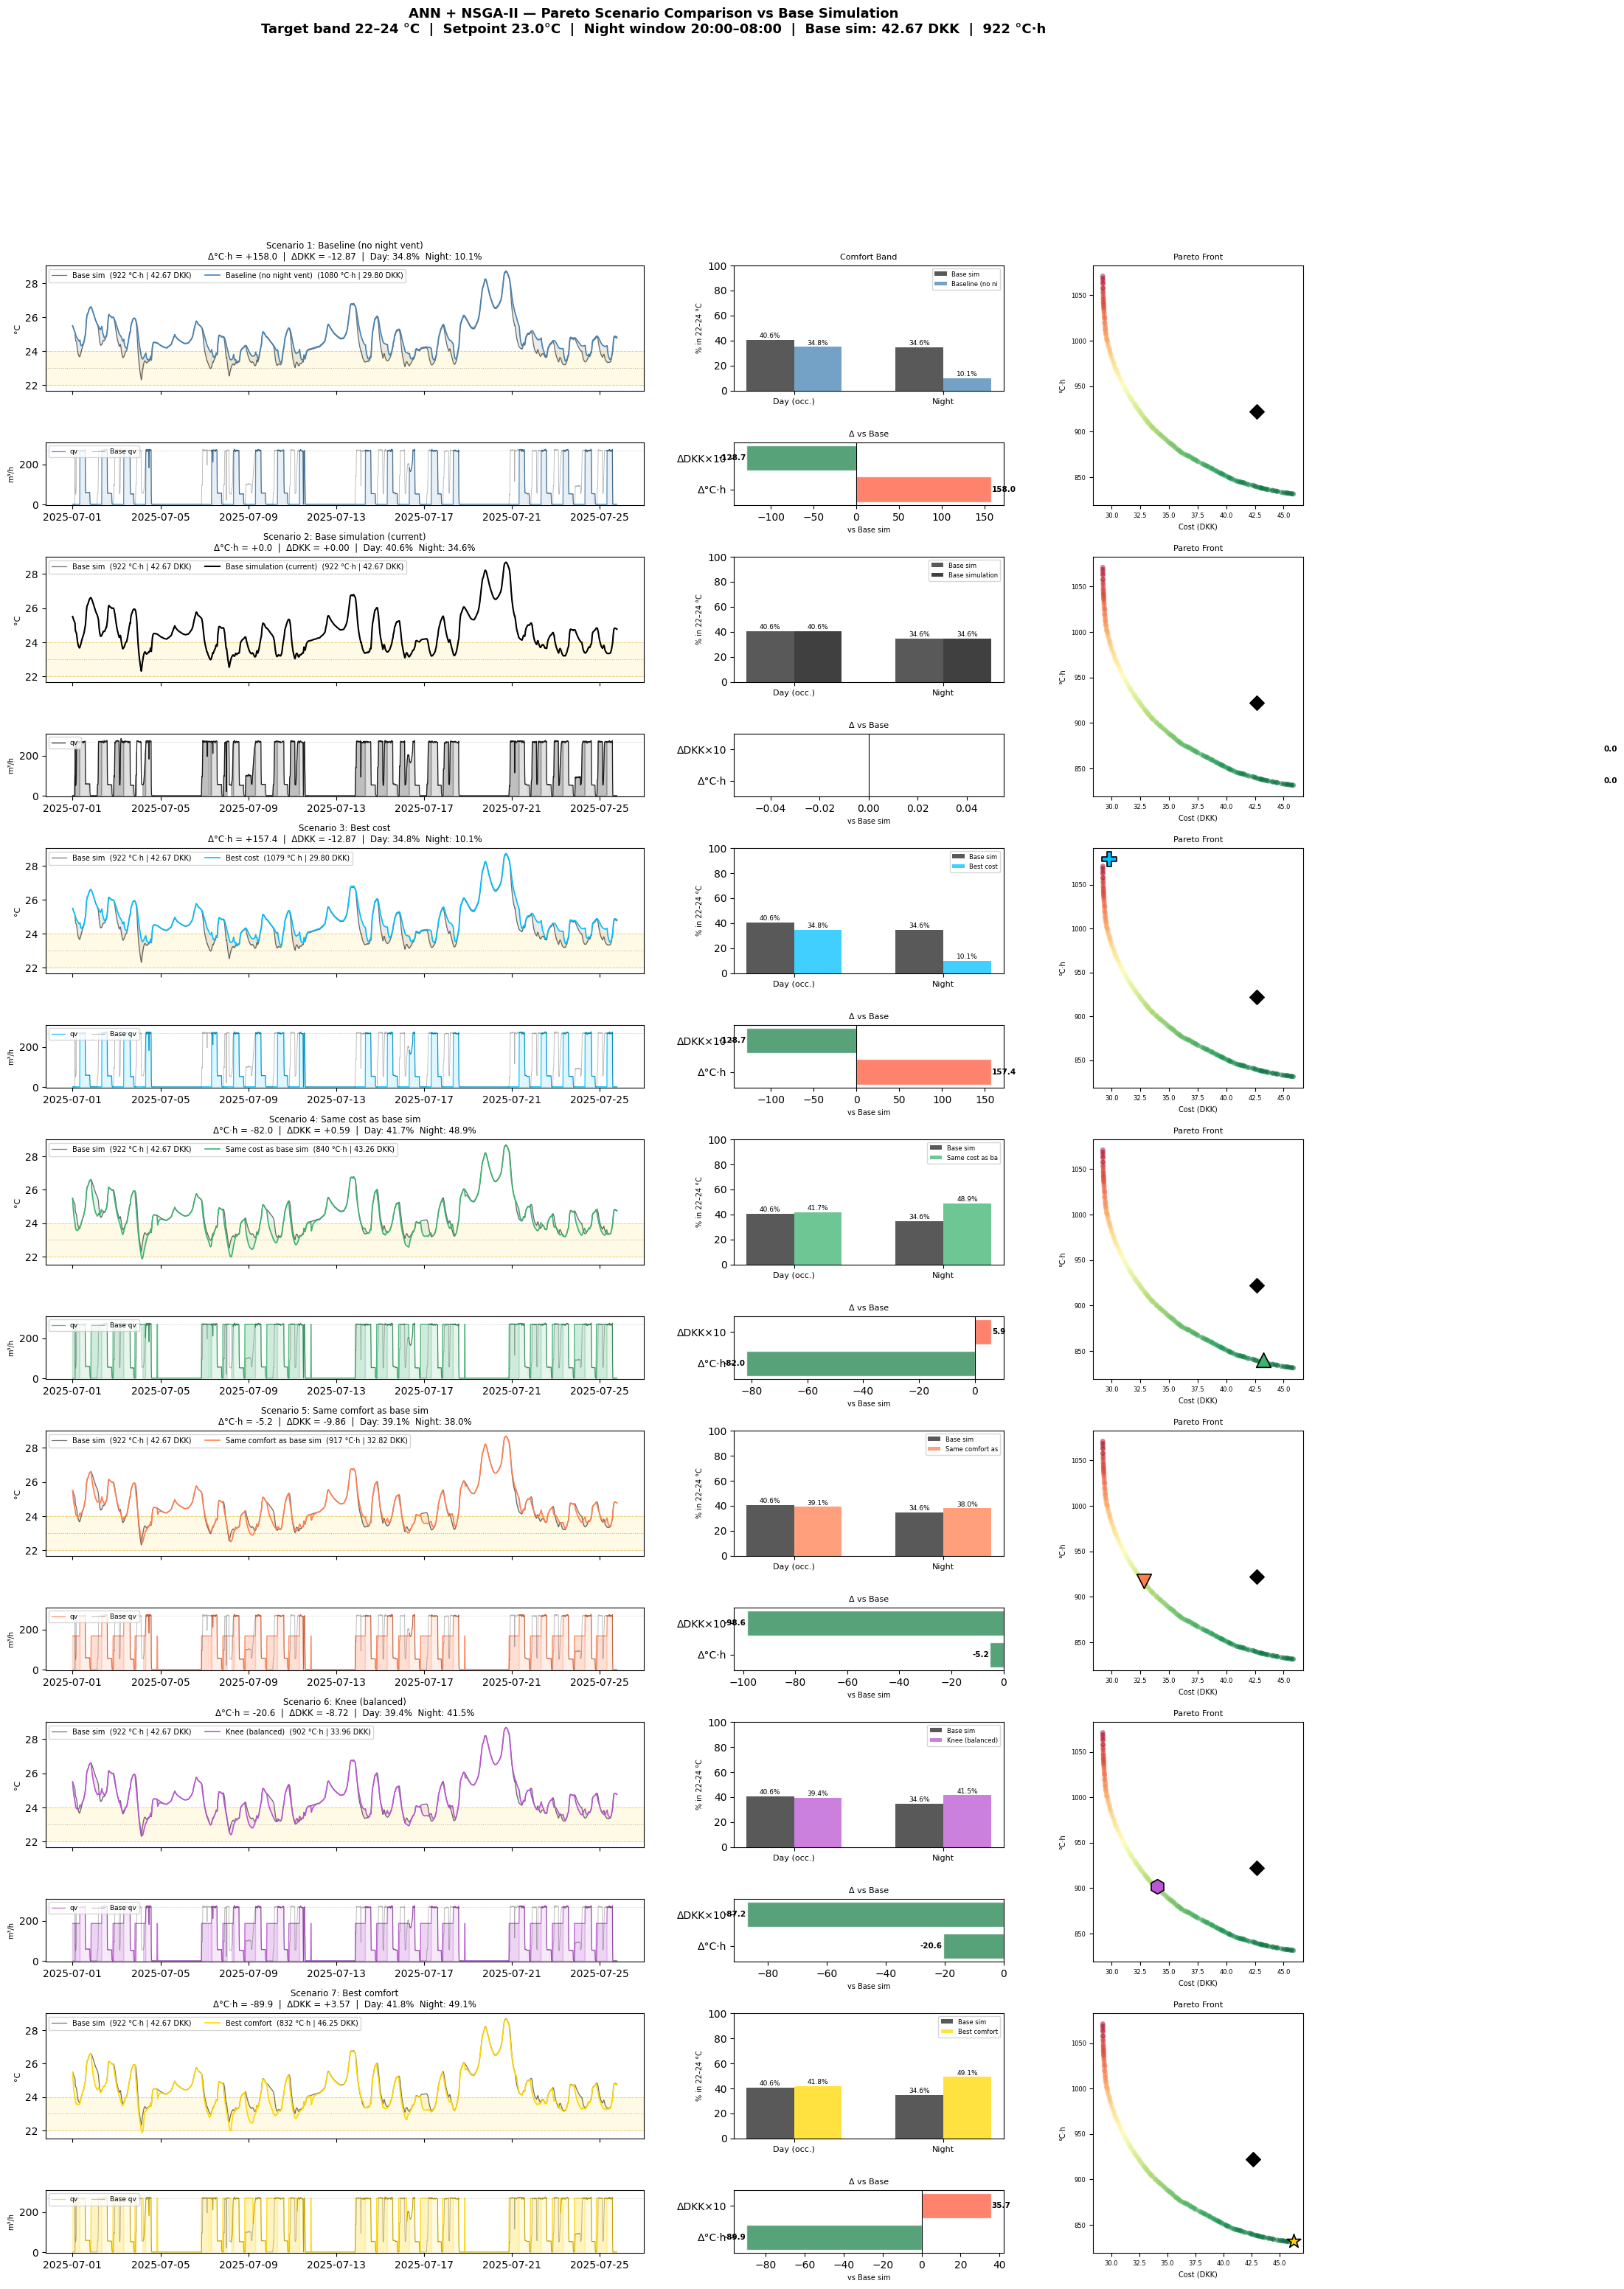

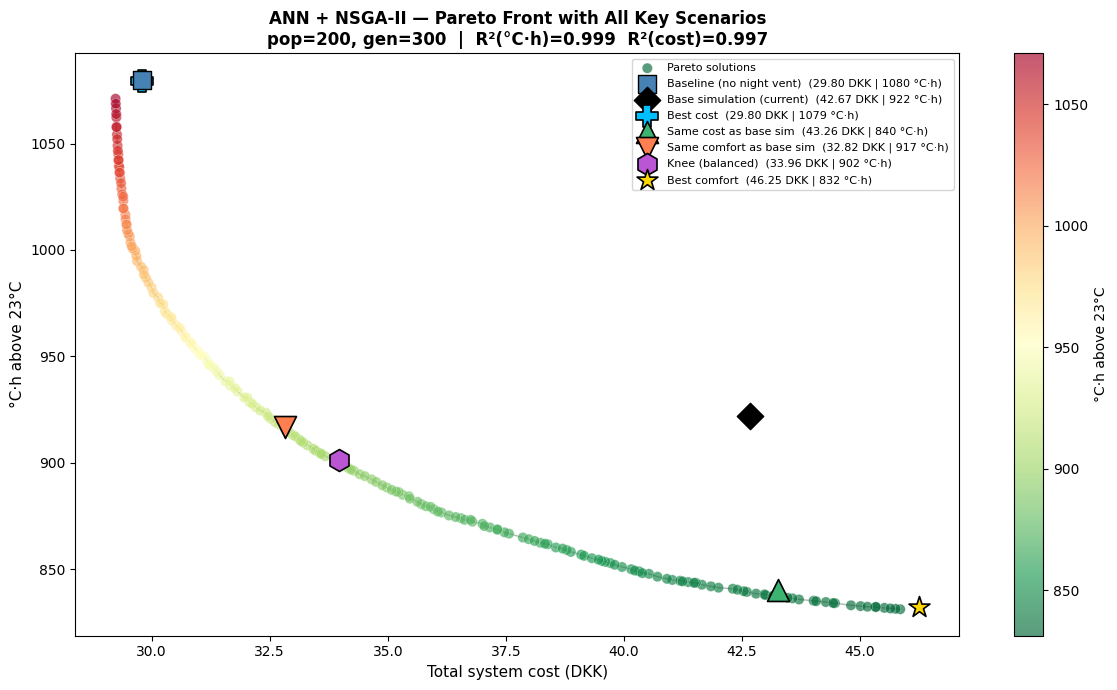

In [17]:
# ════════════════════════════════════════════════════════════════════════════
#  ANN+NSGA-II PARETO COMPARISON — Summary Table + Figure
#
#  Prerequisites (from ANN+NSGA-II block):
#    verified         — dict with keys: Best comfort, Knee (balanced), Best cost
#    F_pareto, X_pareto — full Pareto front arrays
#    dh_above_ref, cost_ref, pct_occ_ref, pct_night_ref, Ti_ref
#    dh_above_base, cost_baseline, pct_occ_base, Ti_baseline
#    index, occ_mask, all_night_mask, weekday_night_mask, weekday_day_mask
#    ta_ok_mask, T_TARGET, T_cat1_min, T_cat1_max, QV_MAX, dt_h
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# ── Find iso-cost and iso-comfort Pareto solutions ───────────────────────────
# 1. Same cost as base sim → best comfort achievable at that cost
_cost_diff = np.abs(F_pareto[:, 1] - cost_ref)
iso_cost_idx = int(np.argmin(_cost_diff))

# 2. Same comfort as base sim → best cost achievable at that comfort
_dh_diff = np.abs(F_pareto[:, 0] - dh_above_ref)
iso_comfort_idx = int(np.argmin(_dh_diff))

# Re-simulate both with RC model
def _resim(idx, label, color, marker):
    params = X_pareto[idx]
    qv_mod, Tsup_mod = build_X_monthly(params)
    X_mod = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod
    res = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)
    Ti_v      = np.asarray(res['Ti'])
    dh_v, _   = dh_from_target(Ti_v)
    cost_v    = total_system_cost(qv_mod, Ta_arr, Tsup_mod)
    pct_occ_v = pct_in_band(Ti_v, T_cat1_min, T_cat1_max, occ_mask)
    pct_ngt_v = pct_in_band(Ti_v, T_cat1_min, T_cat1_max, all_night_mask)
    return {
        'label': label, 'params': params, 'Ti': Ti_v,
        'qv_mod': qv_mod, 'dh_above': dh_v, 'cost': cost_v,
        'pct_occ': pct_occ_v, 'pct_night': pct_ngt_v,
        'color': color, 'marker': marker,
    }

iso_cost_data    = _resim(iso_cost_idx,    'Same cost as base sim',    'mediumseagreen', '^')
iso_comfort_data = _resim(iso_comfort_idx, 'Same comfort as base sim', 'coral',          'v')

# ── Master scenario list ──────────────────────────────────────────────────────
SCENARIOS = [
    {'label': 'Baseline (no night vent)',
     'Ti': Ti_baseline, 'qv_mod': qv_baseline,
     'dh_above': dh_above_base, 'cost': cost_baseline,
     'pct_occ': pct_occ_base,
     'pct_night': pct_in_band(Ti_baseline, T_cat1_min, T_cat1_max, all_night_mask),
     'color': 'steelblue', 'marker': 's'},

    {'label': 'Base simulation (current)',
     'Ti': Ti_ref, 'qv_mod': qv_arr,
     'dh_above': dh_above_ref, 'cost': cost_ref,
     'pct_occ': pct_occ_ref, 'pct_night': pct_night_ref,
     'color': 'black', 'marker': 'D'},

    {**verified['Best cost'],    'label': 'Best cost'},
    iso_cost_data,   
    iso_comfort_data,
    {**verified['Knee (balanced)'], 'label': 'Knee (balanced)'},
    {**verified['Best comfort'],    'label': 'Best comfort'},
]

# ── SUMMARY TABLE ─────────────────────────────────────────────────────────────
print(f"\n{'═'*96}")
print(f"  ANN + NSGA-II — PARETO COMPARISON TABLE")
print(f"{'═'*96}")
print(f"  {'Scenario':<30} {'Start':>7} {'Stop':>6} {'qv':>5}  "
      f"{'°C·h':>8}  {'Δ°C·h':>7}  {'DKK':>7}  {'ΔDKK':>7}  {'Day%':>6}  {'Night%':>7}")
print(f"  {'-'*94}")
for s in SCENARIOS:
    p = s.get('params', None)
    start_str = f"{p[0]:.1f}h" if p is not None else "—"
    stop_str  = f"{p[1]:.1f}h" if p is not None else "—"
    qv_str    = f"{p[2]:.0f}"  if p is not None else "—"
    d_dh   = s['dh_above'] - dh_above_ref
    d_cost = s['cost']     - cost_ref
    d_dh_str   = f"{d_dh:+.1f}"   if s['label'] != 'Base simulation (current)' else "—"
    d_cost_str = f"{d_cost:+.2f}" if s['label'] != 'Base simulation (current)' else "—"
    print(f"  {s['label']:<30} {start_str:>7} {stop_str:>6} {qv_str:>5}  "
          f"{s['dh_above']:>8.1f}  {d_dh_str:>7}  {s['cost']:>7.2f}  "
          f"{d_cost_str:>7}  {s['pct_occ']:>5.1f}%  {s['pct_night']:>6.1f}%")
print(f"  {'═'*94}")


# ════════════════════════════════════════════════════════════════════════════
#  FIGURE — Dashboard comparison
# ════════════════════════════════════════════════════════════════════════════
N_SCEN = len(SCENARIOS)
_ref   = SCENARIOS[1]   # base simulation

fig = plt.figure(figsize=(22, 5 * N_SCEN))
gs  = gridspec.GridSpec(
    N_SCEN * 2, 3,
    figure=fig,
    width_ratios=[4, 1.8, 1.4],
    height_ratios=[2, 1] * N_SCEN,
    hspace=0.55, wspace=0.25
)
fig.suptitle(
    'ANN + NSGA-II — Pareto Scenario Comparison vs Base Simulation\n'
    f'Target band {T_cat1_min:.0f}–{T_cat1_max:.0f} °C  |  Setpoint {T_TARGET}°C  |  '
    f'Night window {NIGHT_START:02d}:00–{NIGHT_STOP:02d}:00  |  '
    f'Base sim: {cost_ref:.2f} DKK  |  {dh_above_ref:.0f} °C·h',
    fontsize=13, fontweight='bold'
)

for row, s in enumerate(SCENARIOS):
    r_temp = 2 * row
    r_qv   = 2 * row + 1

    ax_ts  = fig.add_subplot(gs[r_temp, 0])
    ax_qv  = fig.add_subplot(gs[r_qv,   0], sharex=ax_ts)
    ax_bar = fig.add_subplot(gs[r_temp,  1])
    ax_met = fig.add_subplot(gs[r_qv,    1])
    ax_fp  = fig.add_subplot(gs[r_temp:r_temp+2, 2])

    is_ref = s['label'] == 'Base simulation (current)'
    color  = s['color']

    # ── Temperature panel ────────────────────────────────────────────────────
    ax_ts.plot(index, _ref['Ti'], color='black', lw=0.9, alpha=0.55,
               label=f'Base sim  ({_ref["dh_above"]:.0f} °C·h | {_ref["cost"]:.2f} DKK)',
               zorder=3)
    ax_ts.plot(index, s['Ti'], color=color, lw=1.2 if not is_ref else 1.5,
               label=f'{s["label"]}  ({s["dh_above"]:.0f} °C·h | {s["cost"]:.2f} DKK)',
               zorder=4)
    ax_ts.axhspan(T_cat1_min, T_cat1_max, alpha=0.10, color='gold')
    ax_ts.axhline(T_cat1_max, color='goldenrod', lw=0.7, ls='--', alpha=0.5)
    ax_ts.axhline(T_cat1_min, color='goldenrod', lw=0.7, ls='--', alpha=0.5)
    ax_ts.axhline(T_TARGET,   color='grey',      lw=0.7, ls=':',  alpha=0.6)
    if not is_ref:
        ax_ts.fill_between(index, _ref['Ti'], s['Ti'],
            where=(_ref['Ti'] > s['Ti']), alpha=0.12, color=color)
        ax_ts.fill_between(index, _ref['Ti'], s['Ti'],
            where=(_ref['Ti'] < s['Ti']), alpha=0.08, color='black')
    d_dh   = s['dh_above'] - _ref['dh_above']
    d_cost = s['cost']     - _ref['cost']
    ax_ts.set_title(
        f'Scenario {row+1}: {s["label"]}\n'
        f'Δ°C·h = {d_dh:+.1f}  |  ΔDKK = {d_cost:+.2f}  |  '
        f'Day: {s["pct_occ"]:.1f}%  Night: {s["pct_night"]:.1f}%',
        fontsize=8.5
    )
    ax_ts.set_ylabel('°C', fontsize=8)
    ax_ts.legend(fontsize=7, loc='upper left', ncol=2)
    plt.setp(ax_ts.get_xticklabels(), visible=False)

    # ── qv panel ─────────────────────────────────────────────────────────────
    ax_qv.plot(index, s['qv_mod'], color=color, lw=0.9, alpha=0.85, label='qv')
    if not is_ref:
        ax_qv.plot(index, _ref['qv_mod'], color='black', lw=0.6, alpha=0.3, label='Base qv')
    ax_qv.fill_between(index, s['qv_mod'], 0,
        where=weekday_night_mask & ta_ok_mask, alpha=0.25, color=color)
    ax_qv.fill_between(index, s['qv_mod'], 0,
        where=weekday_day_mask, alpha=0.12, color=color)
    ax_qv.axhline(QV_MAX, color='black', lw=0.4, ls=':', alpha=0.4)
    ax_qv.set_ylabel('m³/h', fontsize=7)
    ax_qv.set_ylim(-3, QV_MAX * 1.15)
    ax_qv.legend(fontsize=6.5, loc='upper left', ncol=3)

    # ── Comfort bar chart ─────────────────────────────────────────────────────
    x, w = np.arange(2), 0.32
    b_ref = ax_bar.bar(x - w/2, [_ref['pct_occ'], _ref['pct_night']], w,
                       color='black', alpha=0.65, label='Base sim')
    b_alt = ax_bar.bar(x + w/2, [s['pct_occ'],   s['pct_night']  ], w,
                       color=color,   alpha=0.75, label=s['label'][:15])
    for b in list(b_ref) + list(b_alt):
        ax_bar.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                    f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=6.5)
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(['Day (occ.)', 'Night'], fontsize=8)
    ax_bar.set_ylim(0, 100)
    ax_bar.set_ylabel('% in 22–24 °C', fontsize=7)
    ax_bar.legend(fontsize=6, loc='upper right')
    if row == 0:
        ax_bar.set_title('Comfort Band', fontsize=8)

    # ── Metric delta bars ─────────────────────────────────────────────────────
    metrics     = ['Δ°C·h', 'ΔDKK×10']
    delta_vals  = [d_dh, d_cost * 10]   # scale cost for visibility
    bar_colors  = ['tomato' if v > 0 else 'seagreen' for v in delta_vals]
    ax_met.barh(metrics, delta_vals, color=bar_colors, alpha=0.8, edgecolor='white')
    ax_met.axvline(0, color='black', lw=0.8)
    for i, v in enumerate(delta_vals):
        ax_met.text(v + (0.3 if v >= 0 else -0.3), i,
                    f'{v:.1f}', va='center', ha='left' if v >= 0 else 'right',
                    fontsize=7.5, fontweight='bold')
    ax_met.set_xlabel('vs Base sim', fontsize=7)
    ax_met.set_title('Δ vs Base', fontsize=8)

    # ── Pareto front mini-plot ─────────────────────────────────────────────────
    _sort = np.argsort(F_pareto[:, 1])
    ax_fp.scatter(F_pareto[:, 1], F_pareto[:, 0],
                  c=F_pareto[:, 0], cmap='RdYlGn_r', s=25, alpha=0.5,
                  edgecolors='none', zorder=2)
    ax_fp.plot(F_pareto[_sort, 1], F_pareto[_sort, 0],
               color='black', lw=0.6, alpha=0.25, zorder=1)
    # Highlight current scenario if it has Pareto params
    if s.get('params') is not None:
        ax_fp.scatter(s['cost'], s['dh_above'],
                      s=200, marker=s['marker'], color=color,
                      edgecolors='black', lw=1.2, zorder=6)
    # Always show base sim
    ax_fp.scatter(_ref['cost'], _ref['dh_above'],
                  s=100, marker='D', color='black', zorder=7,
                  label='Base sim')
    ax_fp.set_xlabel('Cost (DKK)', fontsize=7)
    ax_fp.set_ylabel('°C·h', fontsize=7)
    ax_fp.tick_params(labelsize=6)
    ax_fp.set_title('Pareto Front', fontsize=8)

plt.savefig('ann_nsga2_pareto_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Standalone Pareto summary chart ──────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(12, 7))
_sort = np.argsort(F_pareto[:, 1])
sc = ax.scatter(F_pareto[:, 1], F_pareto[:, 0],
                c=F_pareto[:, 0], cmap='RdYlGn_r', s=55, alpha=0.65,
                edgecolors='white', lw=0.3, zorder=3, label='Pareto solutions')
ax.plot(F_pareto[_sort, 1], F_pareto[_sort, 0],
        color='black', lw=1.0, alpha=0.30, zorder=2)
plt.colorbar(sc, ax=ax, label='°C·h above 23°C')

for s in SCENARIOS:
    if s['label'] in ('Baseline (no night vent)', 'Base simulation (current)'):
        ax.scatter(s['cost'], s['dh_above'],
                   s=180, marker=s['marker'], color=s['color'],
                   edgecolors='black', lw=1.0, zorder=7,
                   label=f'{s["label"]}  ({s["cost"]:.2f} DKK | {s["dh_above"]:.0f} °C·h)')
    elif s.get('params') is not None:
        ax.scatter(s['cost'], s['dh_above'],
                   s=250, marker=s['marker'], color=s['color'],
                   edgecolors='black', lw=1.2, zorder=6,
                   label=f'{s["label"]}  ({s["cost"]:.2f} DKK | {s["dh_above"]:.0f} °C·h)')

ax.set_xlabel('Total system cost (DKK)', fontsize=11)
ax.set_ylabel('°C·h above 23°C', fontsize=11)
ax.set_title(
    'ANN + NSGA-II — Pareto Front with All Key Scenarios\n'
    f'pop={NSGA_POP}, gen={NSGA_GEN}  |  R²(°C·h)={r2_dh:.3f}  R²(cost)={r2_cost:.3f}',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('ann_nsga2_pareto_summary.png', dpi=150, bbox_inches='tight')
plt.show()



════════════════════════════════════════════════════════════════════════════════════════════════════
  ANN + NSGA-II — PARETO COMPARISON TABLE
════════════════════════════════════════════════════════════════════════════════════════════════════
  Scenario                           Start   Stop    qv      °C·h    Δ°C·h      DKK     ΔDKK    Day%   Night%
  --------------------------------------------------------------------------------------------------
  Baseline (no night vent)               —      —     —    1080.0   +158.0    29.80   -12.87   34.8%    10.1%
  Base simulation (current)              —      —     —     922.1        —    42.67        —   40.6%    34.6%
  Best cost                          20.2h   8.0h     1    1079.5   +157.4    29.80   -12.87   34.8%    10.1%
  Same cost as base sim              20.0h   7.3h   270     840.1    -82.0    43.26    +0.59   41.7%    48.9%
  Same comfort as base sim           20.1h   8.0h   168     916.9     -5.2    32.82    -9.86   39.1%    

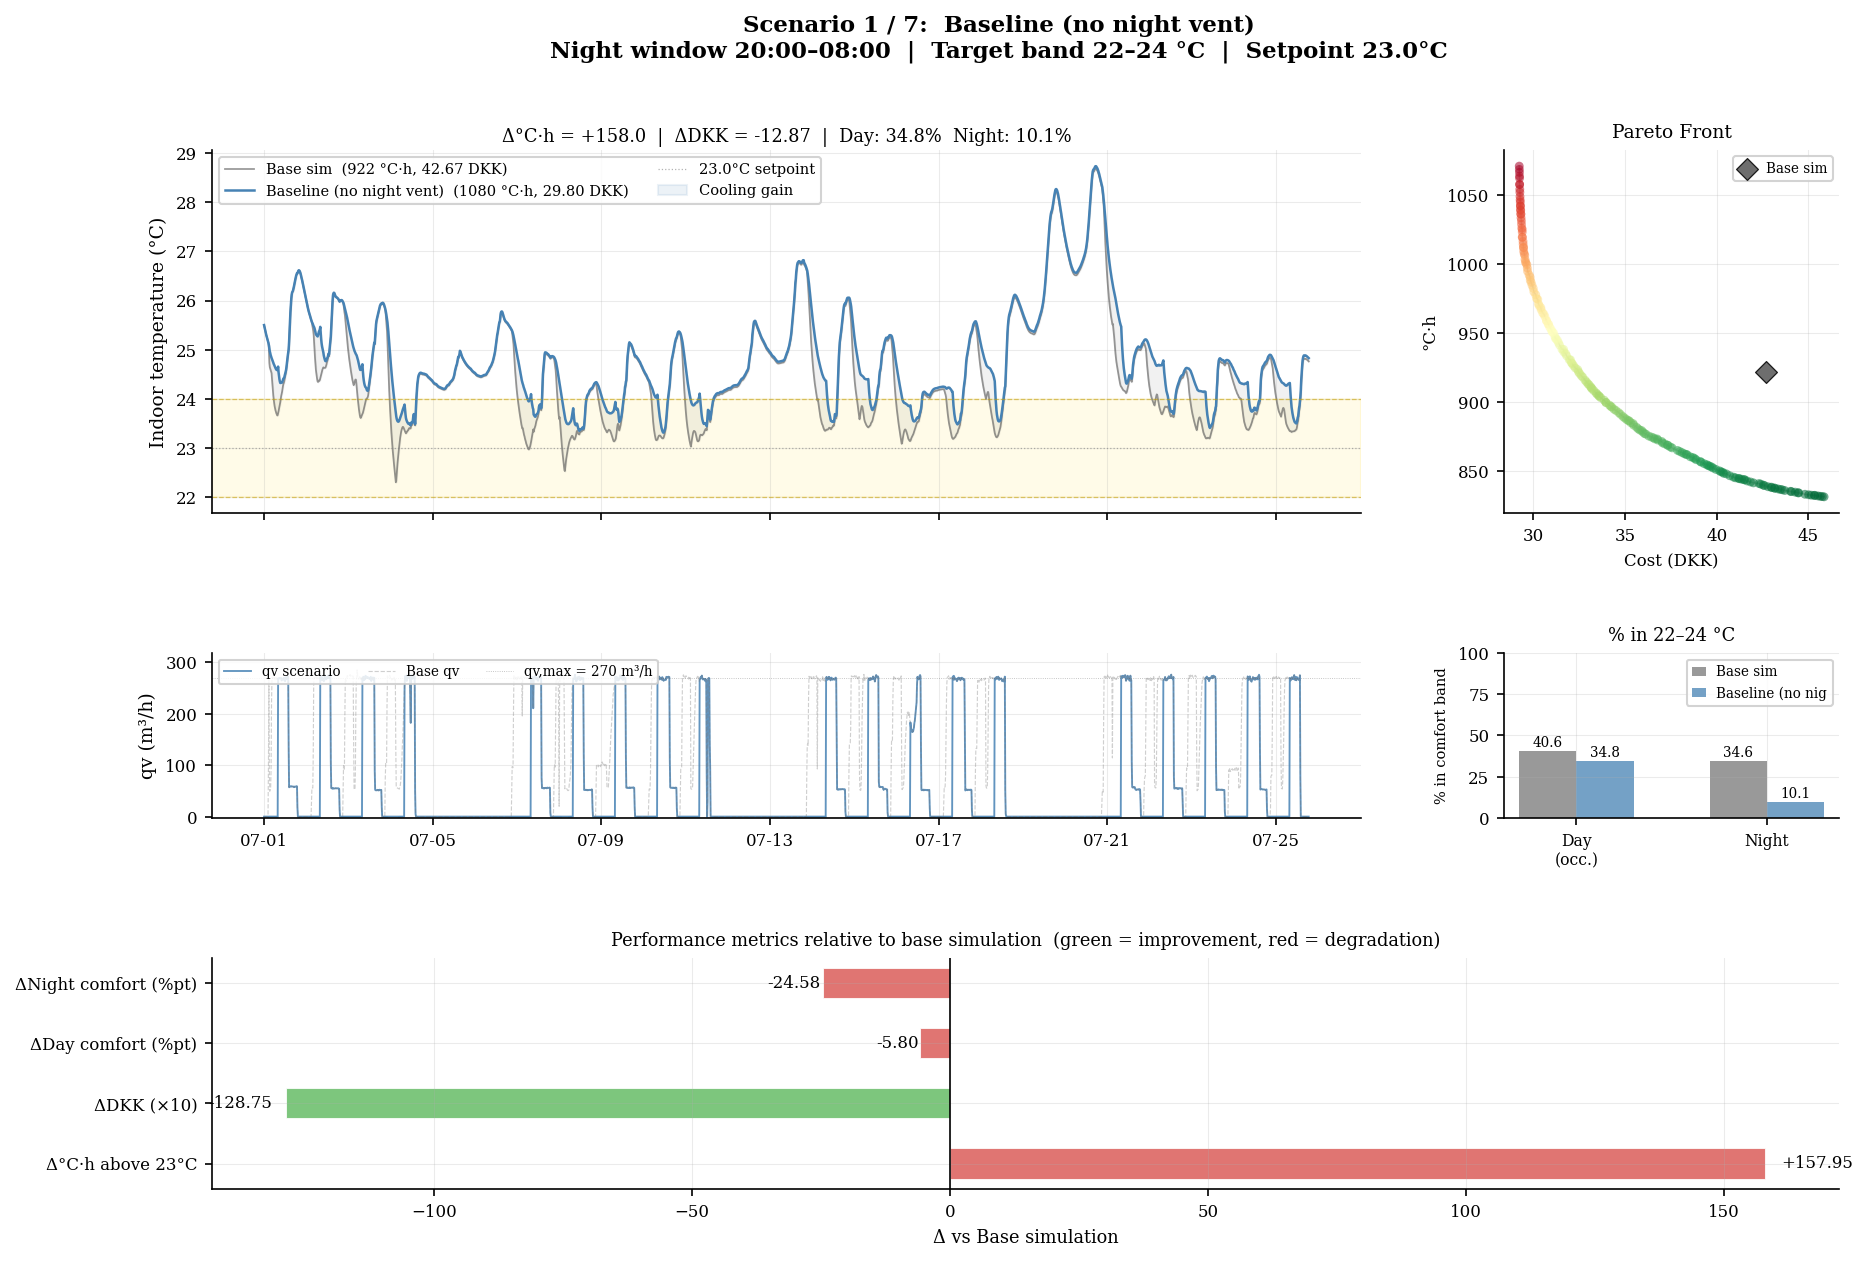

  Saved: ann_pareto_s1_baseline_no_night_vent.png


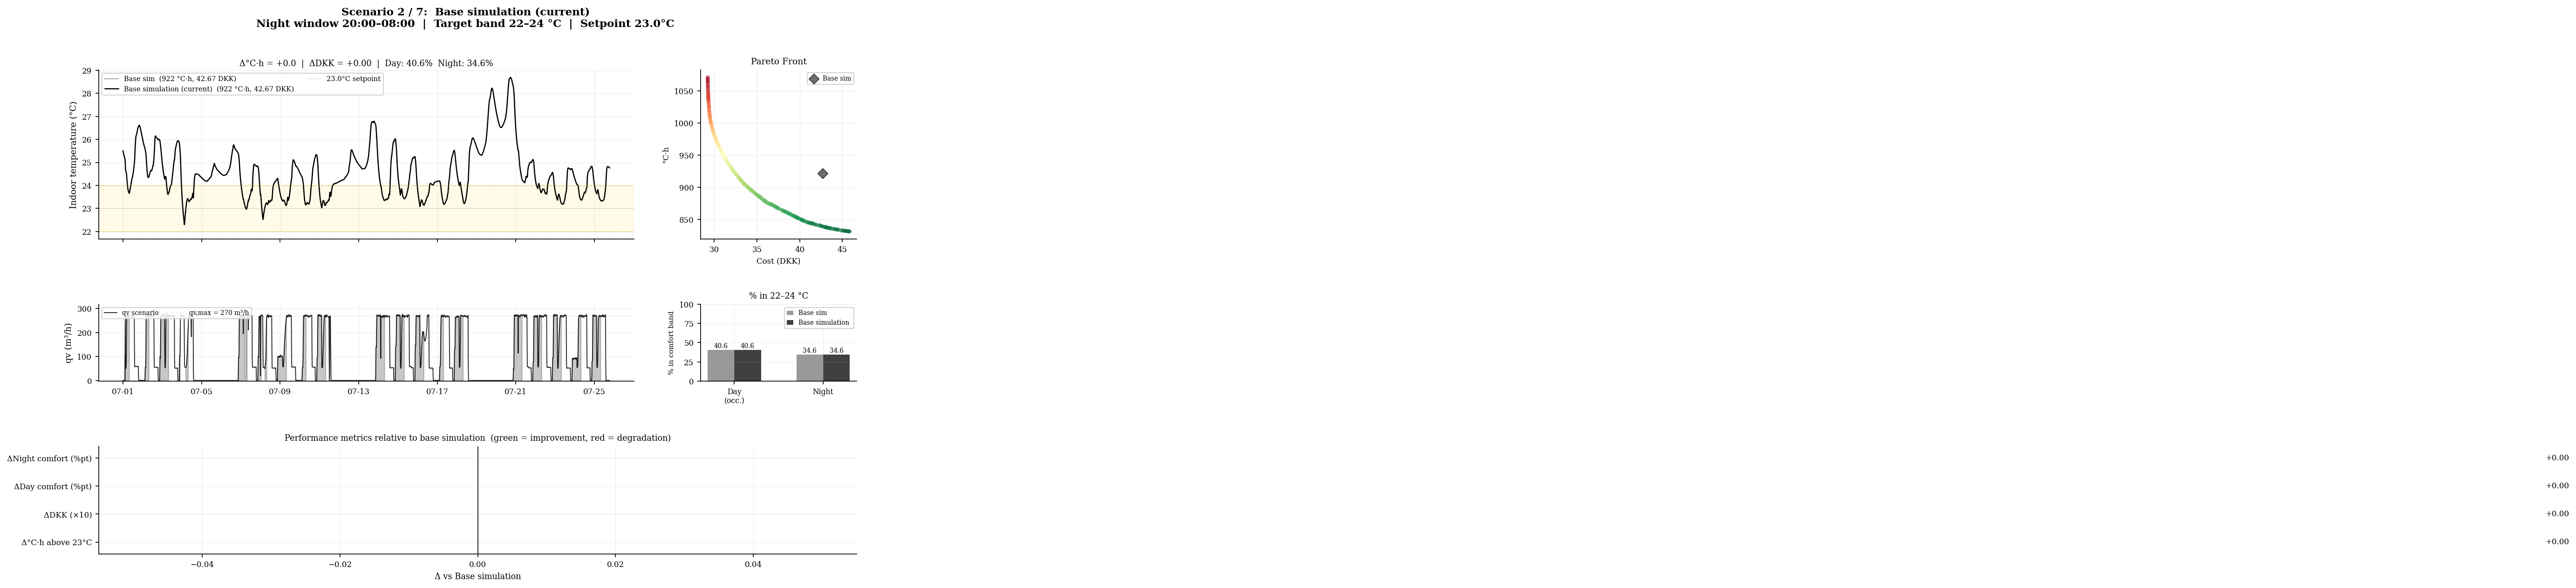

  Saved: ann_pareto_s2_base_simulation_current.png


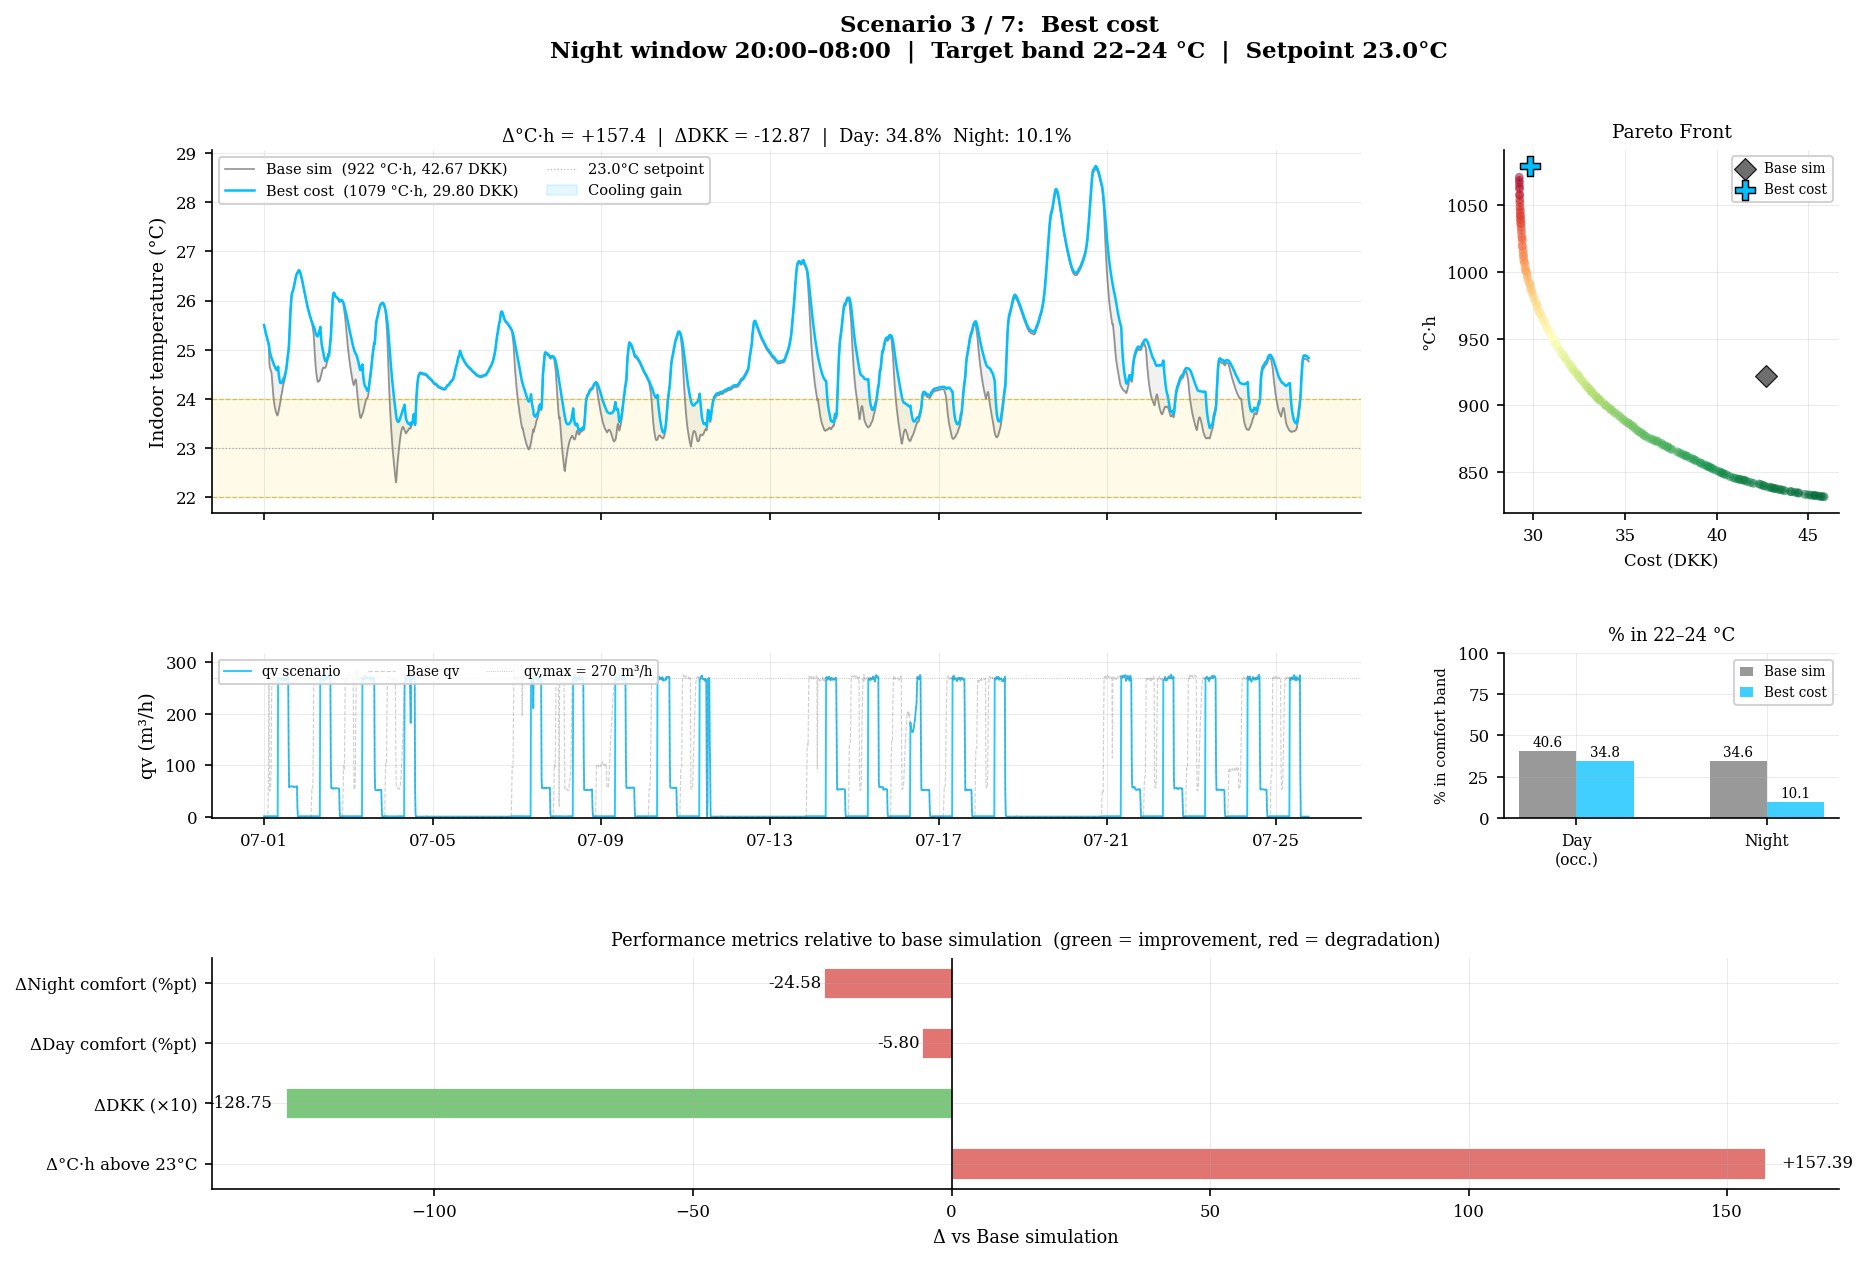

  Saved: ann_pareto_s3_best_cost.png


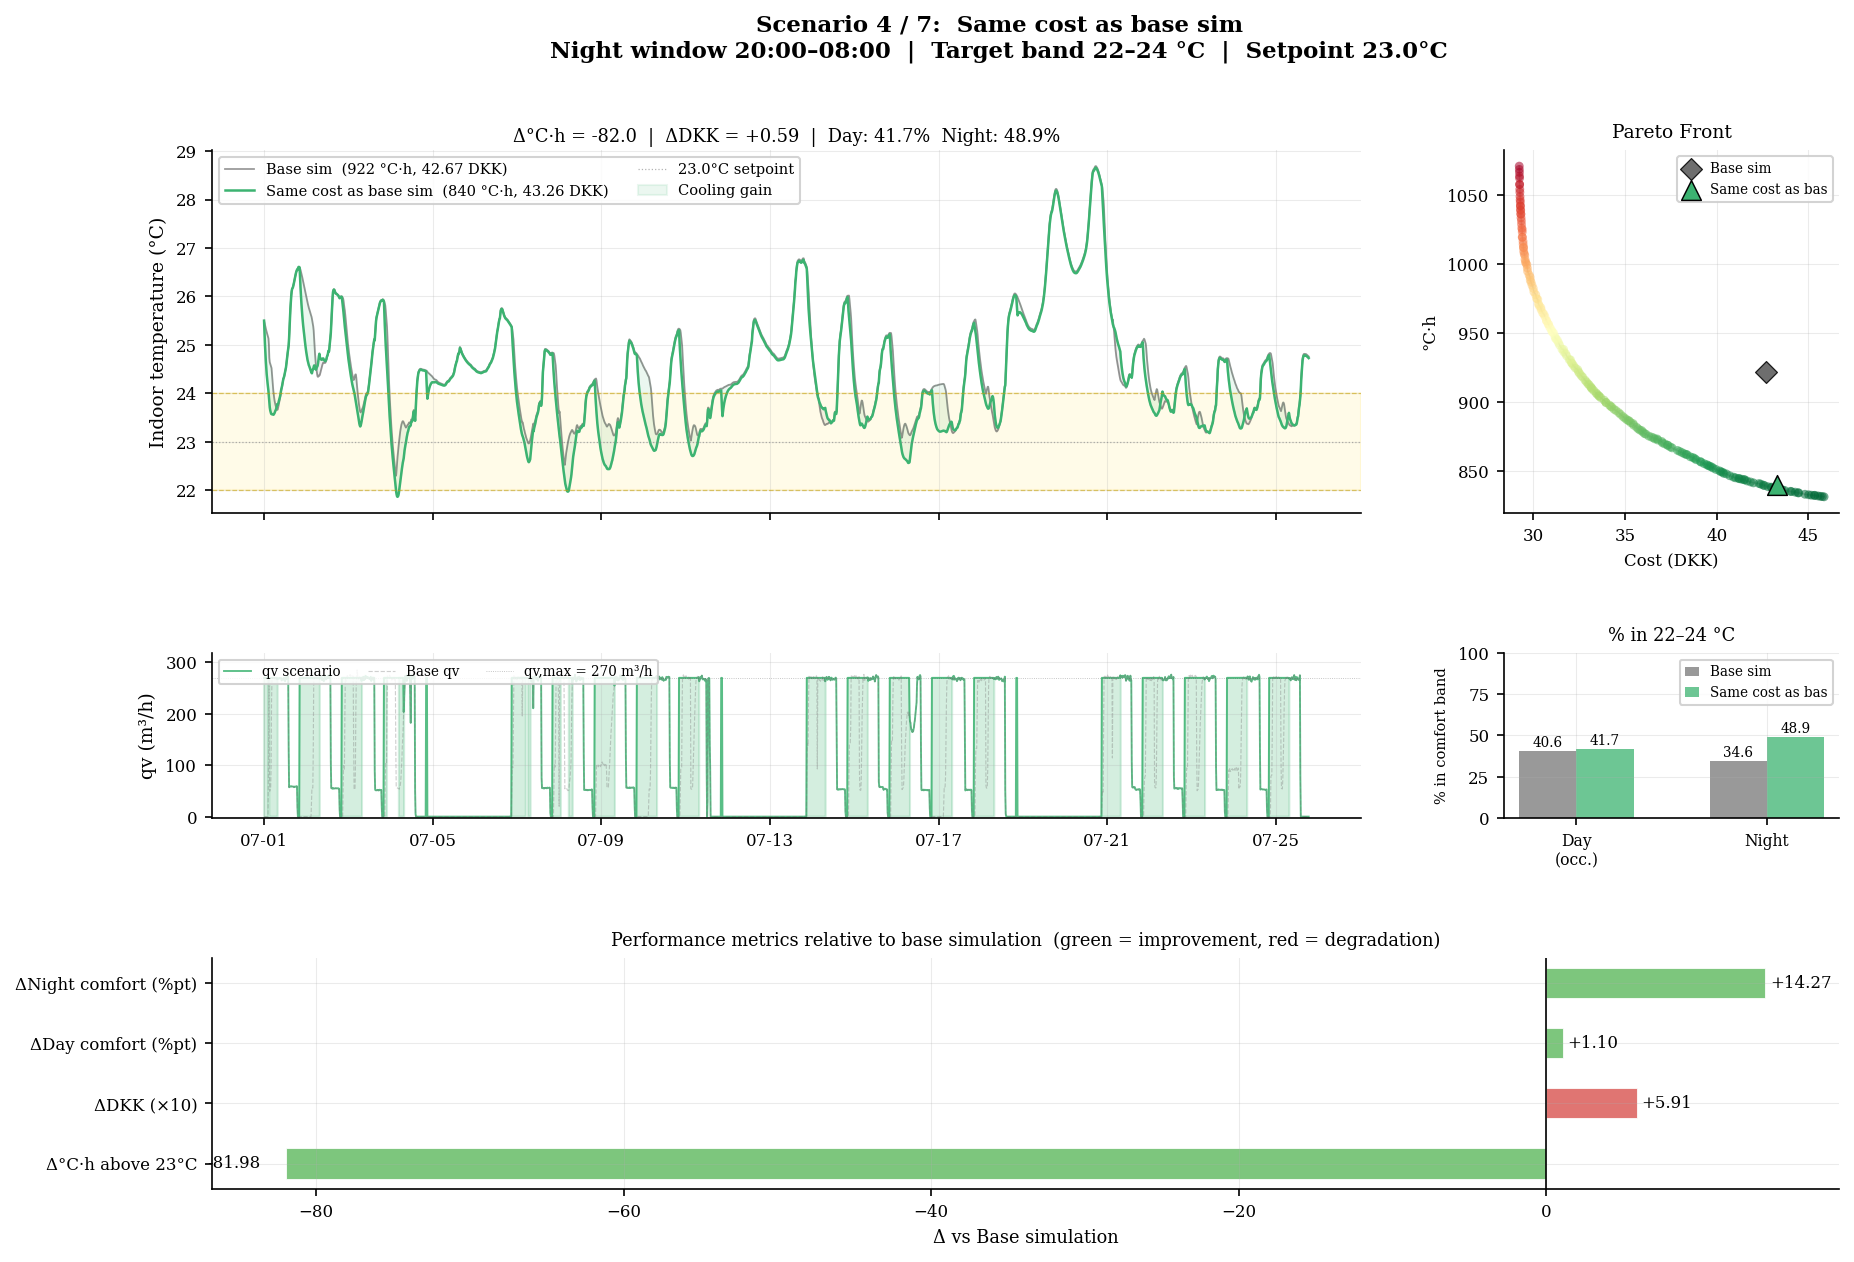

  Saved: ann_pareto_s4_same_cost_as_base_sim.png


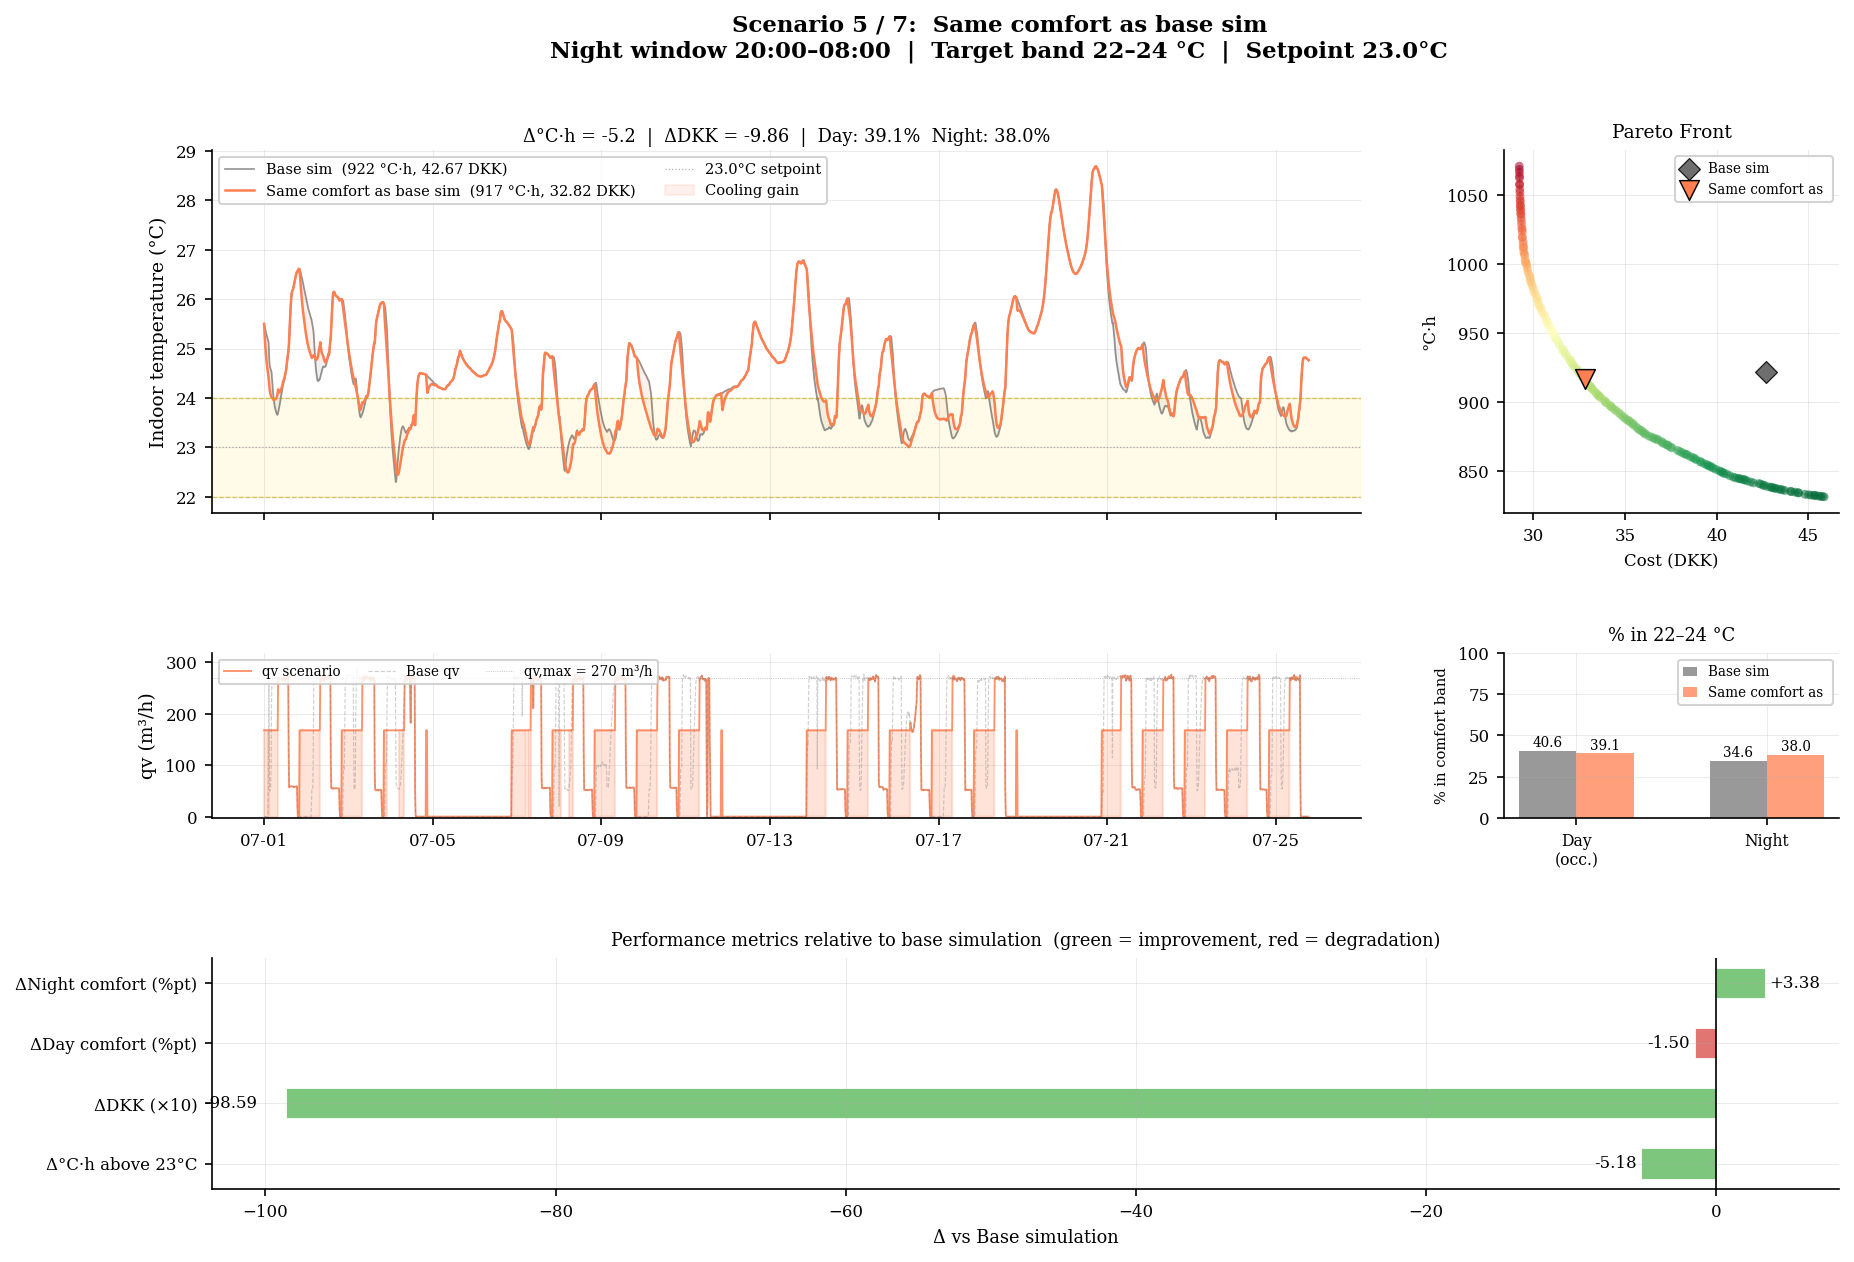

  Saved: ann_pareto_s5_same_comfort_as_base_sim.png


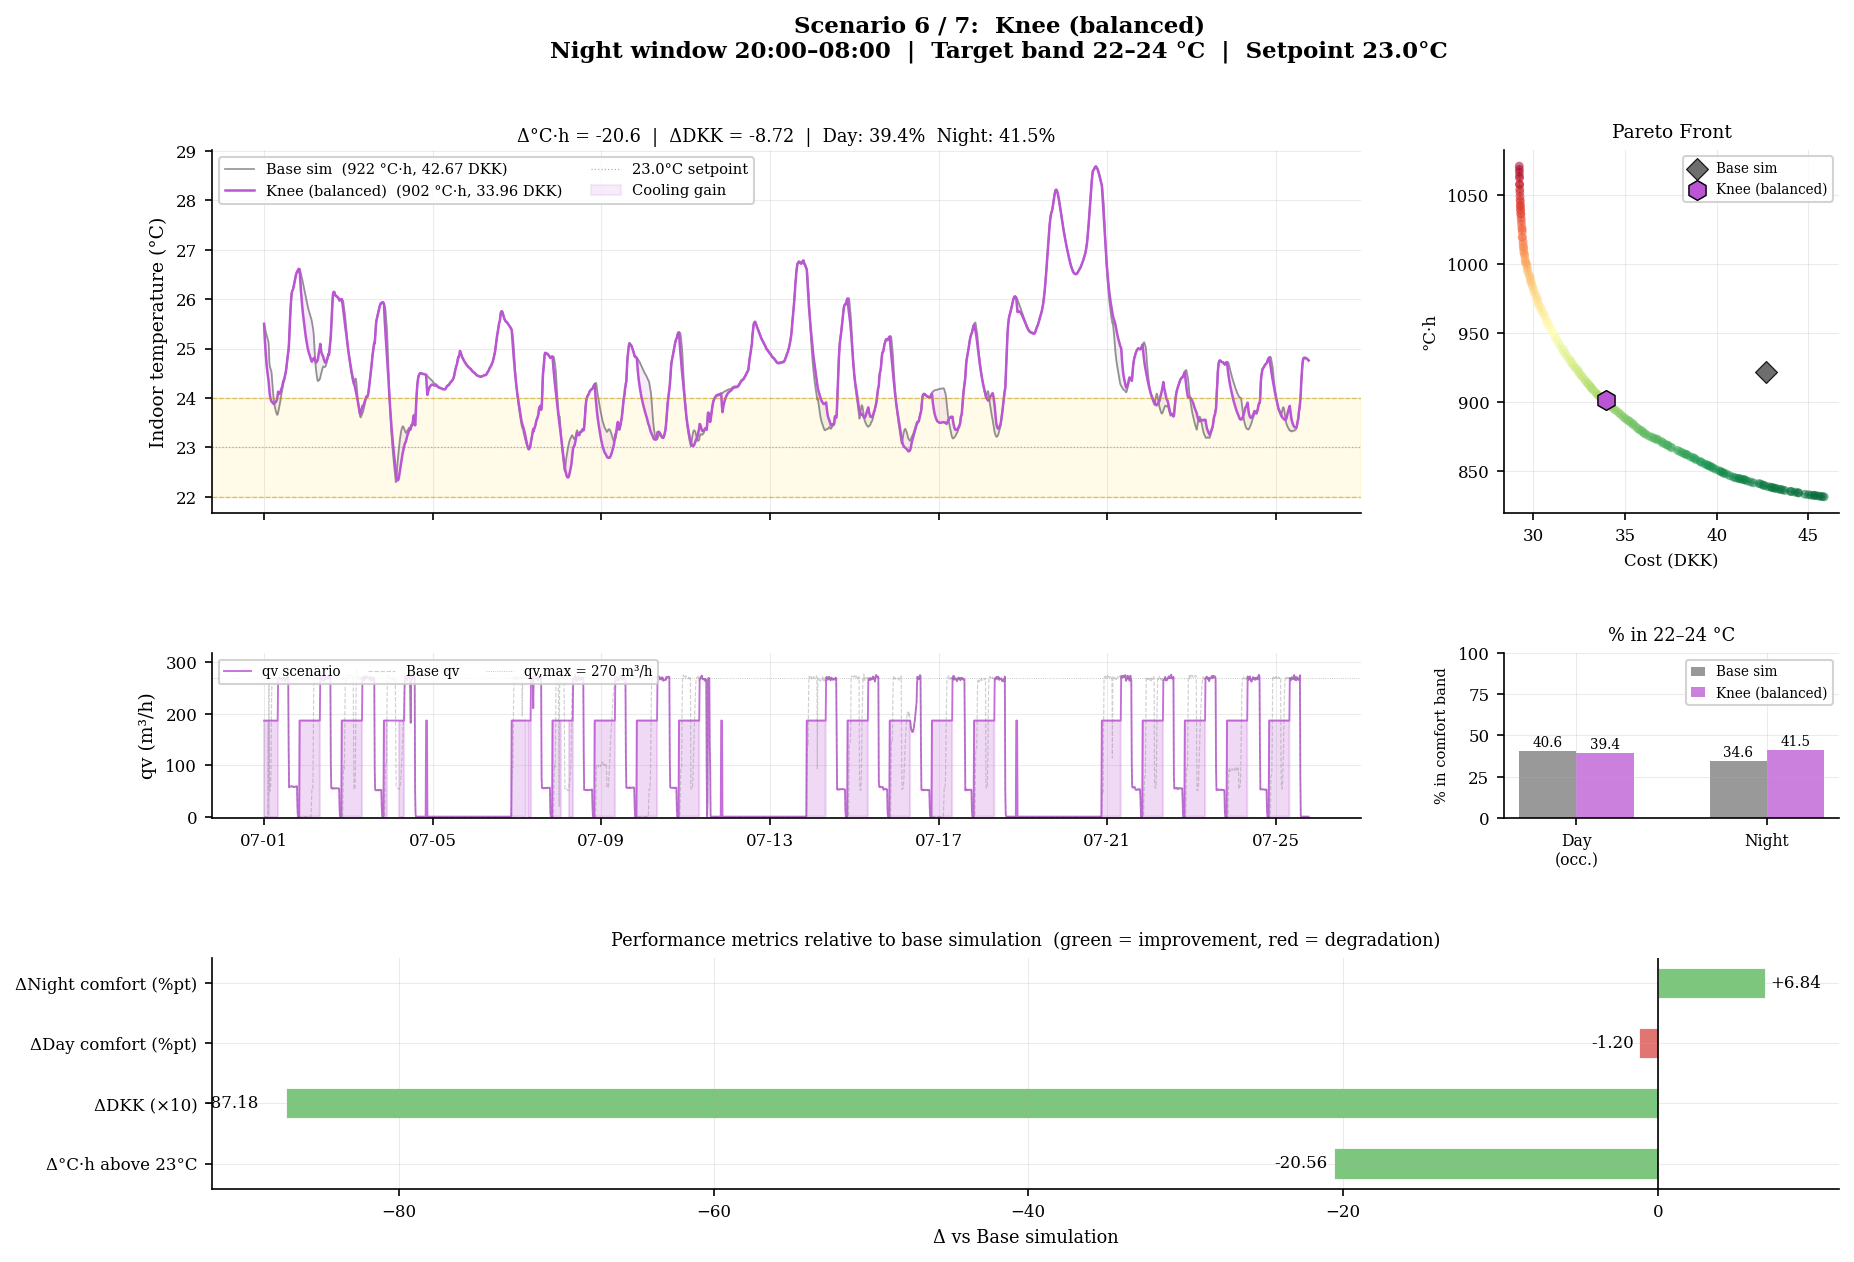

  Saved: ann_pareto_s6_knee_balanced.png


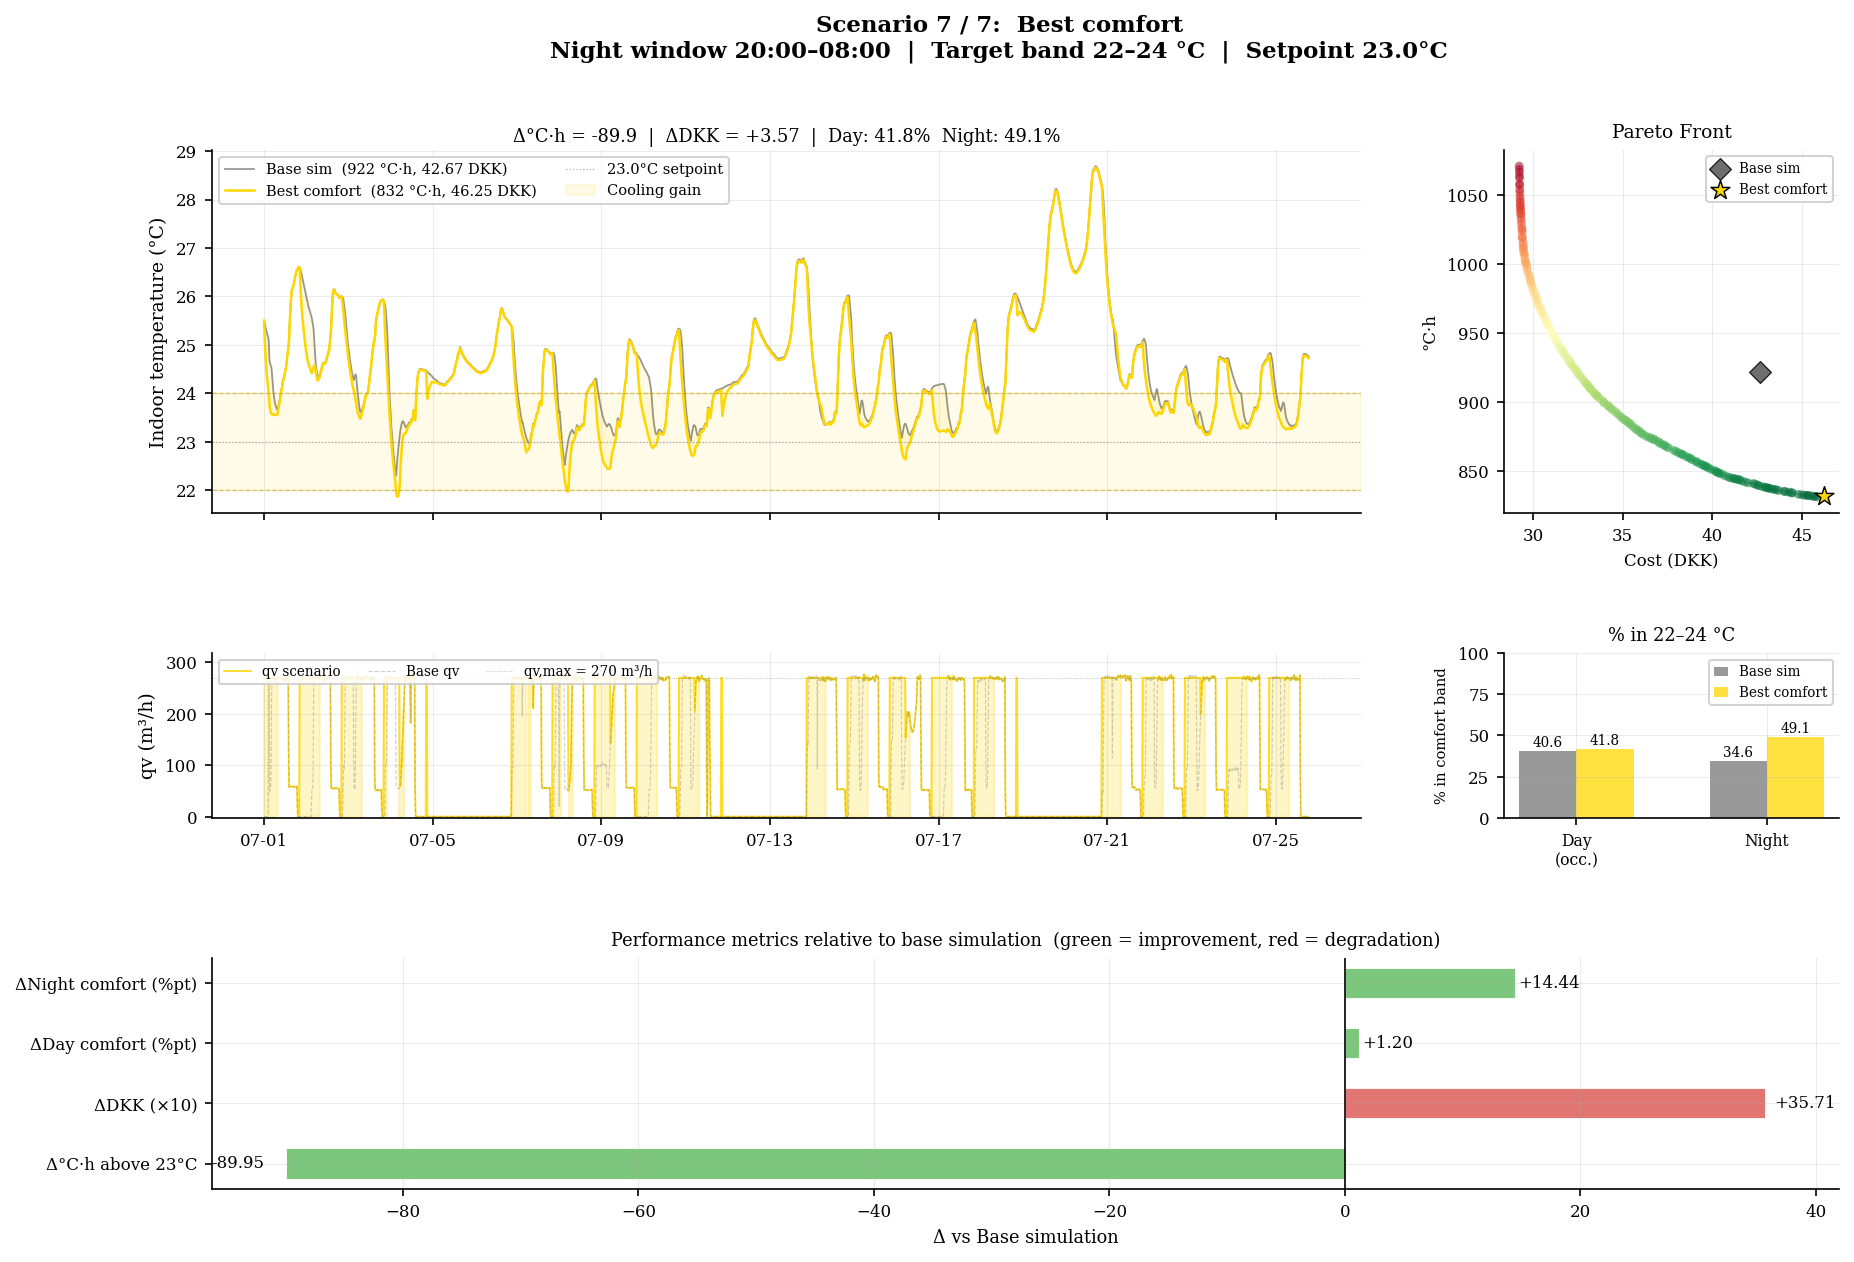

  Saved: ann_pareto_s7_best_comfort.png


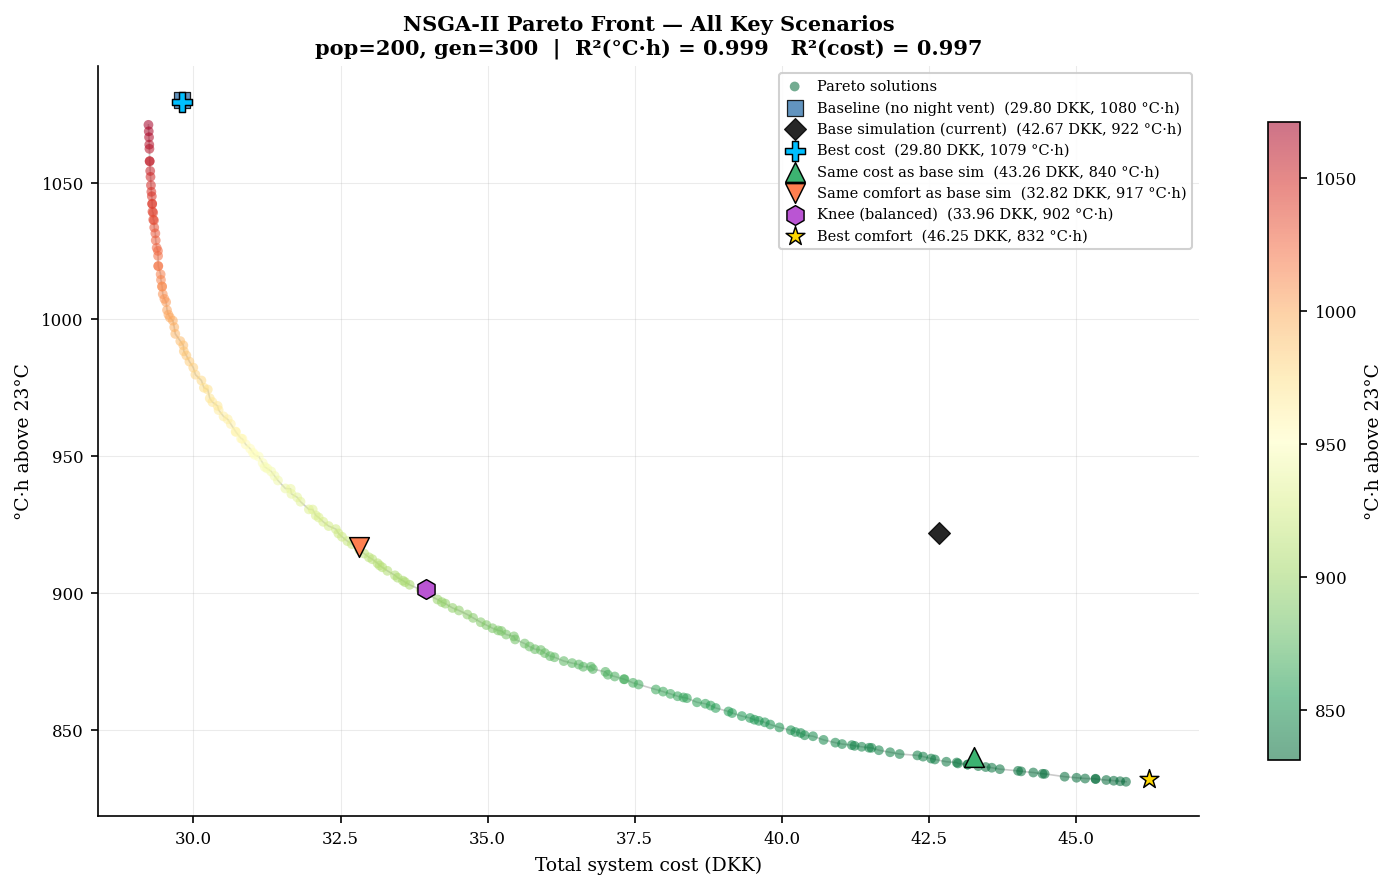

  Saved: ann_nsga2_pareto_summary.png


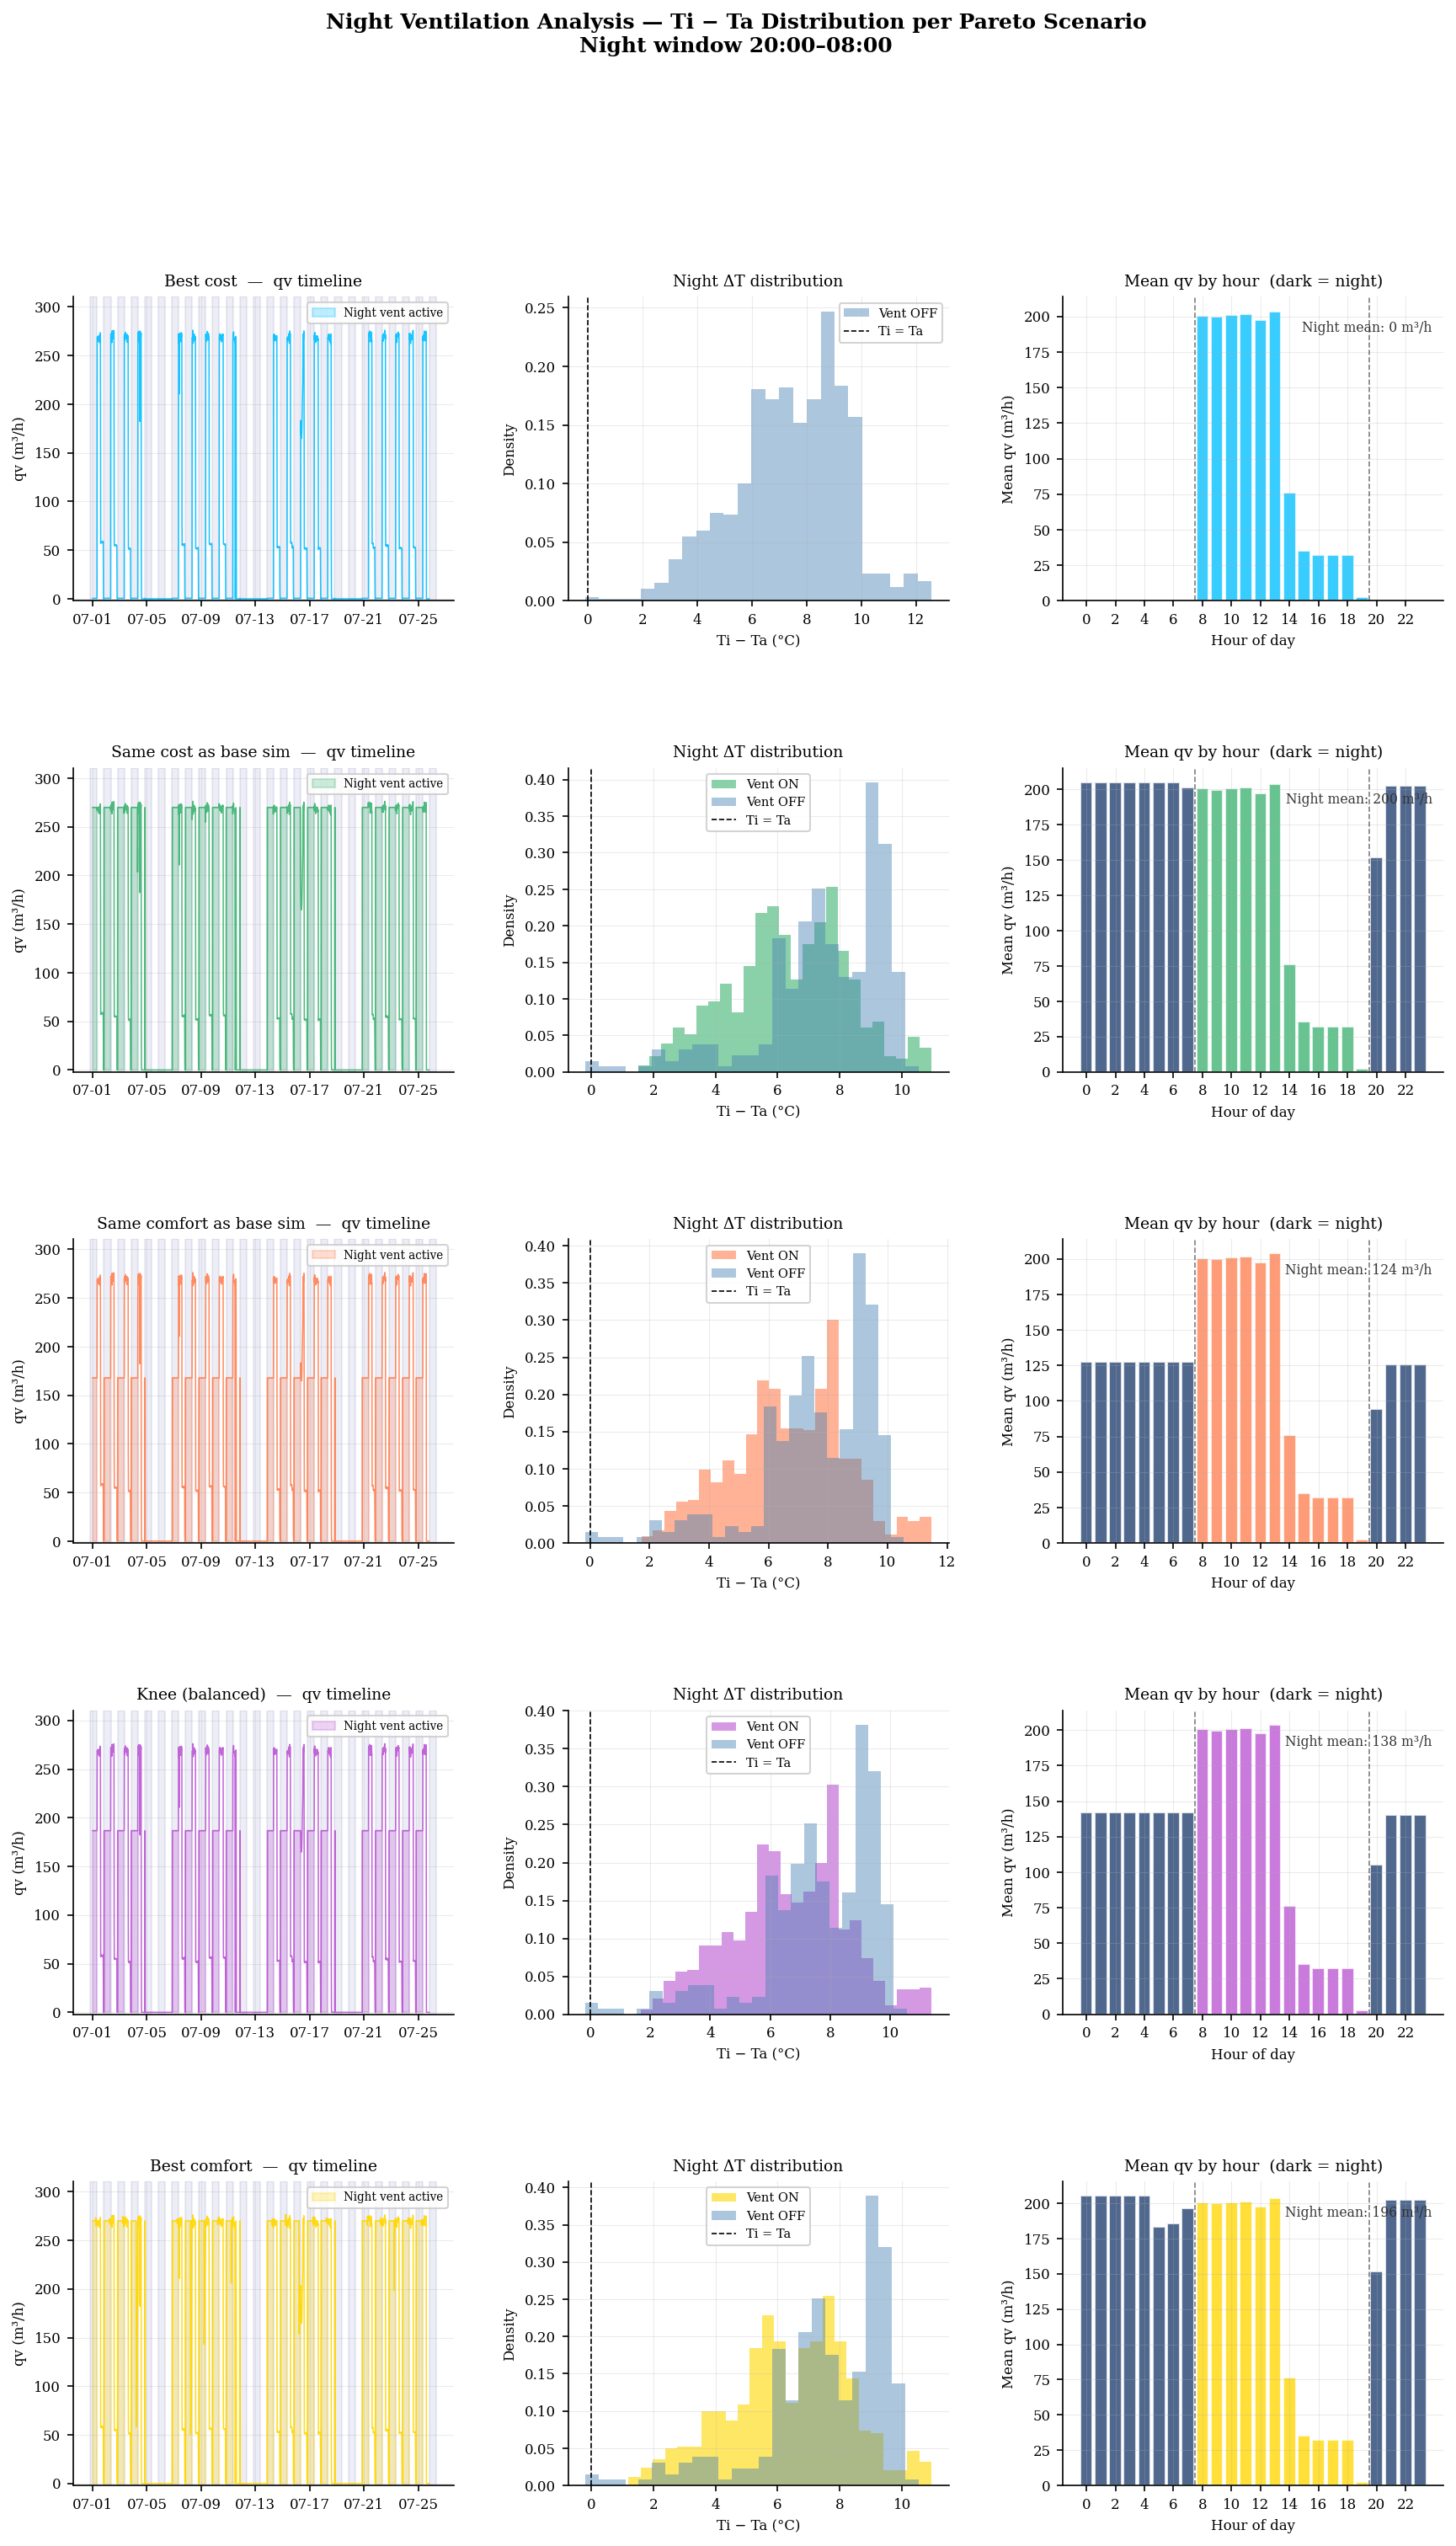

  Saved: night_vent_analysis_scenarios.png

  ✓  All figures saved.


In [18]:
# ════════════════════════════════════════════════════════════════════════════
#  ANN+NSGA-II — INDIVIDUAL SCENARIO FIGURES + NIGHT VENT ANALYSIS
#
#  Produces:
#    ann_pareto_scenario_{i}_{label}.png  — one figure per scenario (7 total)
#    ann_nsga2_pareto_summary.png         — single Pareto front, all scenarios
#    night_vent_analysis_scenarios.png    — Ti/Ta ΔT analysis per Pareto solution
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import re

# ── Matplotlib style for scientific report ────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 9,
    'axes.titlesize'   : 10,
    'axes.labelsize'   : 9,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'legend.fontsize'  : 7.5,
    'legend.framealpha': 0.85,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.25,
    'grid.linewidth'   : 0.5,
    'lines.linewidth'  : 1.0,
    'figure.dpi'       : 150,
})

# ── Marker style — small, publication-quality ─────────────────────────────────
MRK = dict(s=60, edgecolors='black', linewidths=0.6, zorder=6)
MRK_KEY = dict(s=90, edgecolors='black', linewidths=0.7, zorder=7)   # key solutions
MRK_REF = dict(s=55, edgecolors='black', linewidths=0.6, zorder=7, alpha=0.85)

# ── Find iso-cost and iso-comfort Pareto solutions ────────────────────────────
_cost_diff    = np.abs(F_pareto[:, 1] - cost_ref)
iso_cost_idx  = int(np.argmin(_cost_diff))

_dh_diff         = np.abs(F_pareto[:, 0] - dh_above_ref)
iso_comfort_idx  = int(np.argmin(_dh_diff))

def _resim(idx, label, color, marker):
    params = X_pareto[idx]
    qv_mod, Tsup_mod = build_X_monthly(params)
    X_mod = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod
    res = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)
    Ti_v      = np.asarray(res['Ti'])
    dh_v, _   = dh_from_target(Ti_v)
    cost_v    = total_system_cost(qv_mod, Ta_arr, Tsup_mod)
    pct_occ_v = pct_in_band(Ti_v, T_cat1_min, T_cat1_max, occ_mask)
    pct_ngt_v = pct_in_band(Ti_v, T_cat1_min, T_cat1_max, all_night_mask)
    return {'label': label, 'params': params, 'Ti': Ti_v,
            'qv_mod': qv_mod, 'dh_above': dh_v, 'cost': cost_v,
            'pct_occ': pct_occ_v, 'pct_night': pct_ngt_v,
            'color': color, 'marker': marker}

iso_cost_data    = _resim(iso_cost_idx,    'Same cost as base sim',    'mediumseagreen', '^')
iso_comfort_data = _resim(iso_comfort_idx, 'Same comfort as base sim', 'coral',          'v')

SCENARIOS = [
    {'label': 'Baseline (no night vent)',
     'Ti': Ti_baseline, 'qv_mod': qv_baseline,
     'dh_above': dh_above_base, 'cost': cost_baseline,
     'pct_occ': pct_occ_base,
     'pct_night': pct_in_band(Ti_baseline, T_cat1_min, T_cat1_max, all_night_mask),
     'color': 'steelblue', 'marker': 's'},
    {'label': 'Base simulation (current)',
     'Ti': Ti_ref, 'qv_mod': qv_arr,
     'dh_above': dh_above_ref, 'cost': cost_ref,
     'pct_occ': pct_occ_ref, 'pct_night': pct_night_ref,
     'color': 'black', 'marker': 'D'},
    {**verified['Best cost'],       'label': 'Best cost'},
    iso_cost_data,
    iso_comfort_data,
    {**verified['Knee (balanced)'], 'label': 'Knee (balanced)'},
    {**verified['Best comfort'],    'label': 'Best comfort'},
]
_ref = SCENARIOS[1]

# ── Print summary table ───────────────────────────────────────────────────────
print(f"\n{'═'*100}")
print(f"  ANN + NSGA-II — PARETO COMPARISON TABLE")
print(f"{'═'*100}")
print(f"  {'Scenario':<32} {'Start':>7} {'Stop':>6} {'qv':>5}  "
      f"{'°C·h':>8}  {'Δ°C·h':>7}  {'DKK':>7}  {'ΔDKK':>7}  {'Day%':>6}  {'Night%':>7}")
print(f"  {'-'*98}")
for s in SCENARIOS:
    p = s.get('params', None)
    start_s = f"{p[0]:.1f}h" if p is not None else "—"
    stop_s  = f"{p[1]:.1f}h" if p is not None else "—"
    qv_s    = f"{p[2]:.0f}"  if p is not None else "—"
    d_dh    = s['dh_above'] - dh_above_ref
    d_cost  = s['cost']     - cost_ref
    d_dh_s  = f"{d_dh:+.1f}"   if s['label'] != 'Base simulation (current)' else "—"
    d_c_s   = f"{d_cost:+.2f}" if s['label'] != 'Base simulation (current)' else "—"
    print(f"  {s['label']:<32} {start_s:>7} {stop_s:>6} {qv_s:>5}  "
          f"{s['dh_above']:>8.1f}  {d_dh_s:>7}  {s['cost']:>7.2f}  "
          f"{d_c_s:>7}  {s['pct_occ']:>5.1f}%  {s['pct_night']:>6.1f}%")
print(f"  {'═'*100}")

# ════════════════════════════════════════════════════════════════════════════
#  INDIVIDUAL FIGURE PER SCENARIO
# ════════════════════════════════════════════════════════════════════════════
_sort_pf = np.argsort(F_pareto[:, 1])

for i, s in enumerate(SCENARIOS):
    is_ref = (s['label'] == 'Base simulation (current)')
    color  = s['color']
    d_dh   = s['dh_above'] - _ref['dh_above']
    d_cost = s['cost']     - _ref['cost']

    fig = plt.figure(figsize=(14, 9))
    gs  = gridspec.GridSpec(3, 3, figure=fig,
                            height_ratios=[2.2, 1.0, 1.4],
                            width_ratios=[3.0, 1.5, 1.5],
                            hspace=0.55, wspace=0.32)

    ax_ts  = fig.add_subplot(gs[0, :2])      # Ti time series (wide)
    ax_qv  = fig.add_subplot(gs[1, :2], sharex=ax_ts)   # qv
    ax_pf  = fig.add_subplot(gs[0,  2])      # Pareto front
    ax_bar = fig.add_subplot(gs[1,  2])      # comfort bar
    ax_met = fig.add_subplot(gs[2, :])       # metrics bar (full width)

    fig.suptitle(
        f'Scenario {i+1} / {len(SCENARIOS)}:  {s["label"]}\n'
        f'Night window {NIGHT_START:02d}:00–{NIGHT_STOP:02d}:00  |  '
        f'Target band {T_cat1_min:.0f}–{T_cat1_max:.0f} °C  |  Setpoint {T_TARGET}°C',
        fontsize=11, fontweight='bold'
    )

    # ── Ti time series ────────────────────────────────────────────────────────
    ax_ts.plot(index, _ref['Ti'], color='#555555', lw=0.85, alpha=0.6,
               label=f'Base sim  ({_ref["dh_above"]:.0f} °C·h, {_ref["cost"]:.2f} DKK)')
    ax_ts.plot(index, s['Ti'], color=color, lw=1.2,
               label=f'{s["label"]}  ({s["dh_above"]:.0f} °C·h, {s["cost"]:.2f} DKK)')
    ax_ts.axhspan(T_cat1_min, T_cat1_max, alpha=0.09, color='gold', zorder=0)
    ax_ts.axhline(T_cat1_max, color='#c8a000', lw=0.6, ls='--', alpha=0.55)
    ax_ts.axhline(T_cat1_min, color='#c8a000', lw=0.6, ls='--', alpha=0.55)
    ax_ts.axhline(T_TARGET,   color='grey',    lw=0.6, ls=':',  alpha=0.6,
                  label=f'{T_TARGET}°C setpoint')
    if not is_ref:
        ax_ts.fill_between(index, _ref['Ti'], s['Ti'],
            where=(_ref['Ti'] > s['Ti']), alpha=0.10, color=color, label='Cooling gain')
        ax_ts.fill_between(index, _ref['Ti'], s['Ti'],
            where=(_ref['Ti'] < s['Ti']), alpha=0.07, color='#444444')
    ax_ts.set_ylabel('Indoor temperature (°C)')
    ax_ts.set_title(
        f'Δ°C·h = {d_dh:+.1f}  |  ΔDKK = {d_cost:+.2f}  |  '
        f'Day: {s["pct_occ"]:.1f}%  Night: {s["pct_night"]:.1f}%',
        fontsize=8.5, pad=4
    )
    ax_ts.legend(loc='upper left', ncol=2, fontsize=7)
    plt.setp(ax_ts.get_xticklabels(), visible=False)

    # ── qv panel ──────────────────────────────────────────────────────────────
    ax_qv.plot(index, s['qv_mod'], color=color, lw=0.9, alpha=0.85, label='qv scenario')
    if not is_ref:
        ax_qv.plot(index, _ref['qv_mod'], color='#777777', lw=0.55,
                   alpha=0.35, ls='--', label='Base qv')
    ax_qv.fill_between(index, s['qv_mod'], 0,
        where=weekday_night_mask & ta_ok_mask, alpha=0.22, color=color)
    ax_qv.axhline(QV_MAX, color='#444444', lw=0.4, ls=':', alpha=0.4,
                  label=f'qv,max = {QV_MAX:.0f} m³/h')
    ax_qv.set_ylabel('qv (m³/h)')
    ax_qv.set_ylim(-3, QV_MAX * 1.18)
    ax_qv.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_qv.legend(loc='upper left', ncol=3, fontsize=6.5)

    # ── Pareto front ──────────────────────────────────────────────────────────
    sc = ax_pf.scatter(F_pareto[:, 1], F_pareto[:, 0],
                       c=F_pareto[:, 0], cmap='RdYlGn_r', s=18,
                       alpha=0.55, edgecolors='none', zorder=2)
    ax_pf.plot(F_pareto[_sort_pf, 1], F_pareto[_sort_pf, 0],
               color='#333333', lw=0.7, alpha=0.25, zorder=1)
    ax_pf.scatter(_ref['cost'], _ref['dh_above'],
                  marker='D', color='#555555', **{**MRK_REF, 'label': 'Base sim'})
    if s.get('params') is not None:
        ax_pf.scatter(s['cost'], s['dh_above'],
                      marker=s['marker'], color=color, **{**MRK_KEY, 'label': s['label'][:16]})
    ax_pf.set_xlabel('Cost (DKK)', fontsize=8)
    ax_pf.set_ylabel('°C·h', fontsize=8)
    ax_pf.set_title('Pareto Front', fontsize=9)
    ax_pf.legend(fontsize=6.5, handlelength=1.2)

    # ── Comfort bar ───────────────────────────────────────────────────────────
    x, w = np.arange(2), 0.30
    b_r = ax_bar.bar(x - w/2, [_ref['pct_occ'], _ref['pct_night']], w,
                     color='#555555', alpha=0.60, label='Base sim')
    b_a = ax_bar.bar(x + w/2, [s['pct_occ'],    s['pct_night']   ], w,
                     color=color,    alpha=0.75, label=s['label'][:16])
    for b in list(b_r) + list(b_a):
        ax_bar.text(b.get_x() + b.get_width()/2, b.get_height() + 0.8,
                    f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=6.5)
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(['Day\n(occ.)', 'Night'], fontsize=7.5)
    ax_bar.set_ylim(0, 100)
    ax_bar.set_ylabel('% in comfort band', fontsize=7)
    ax_bar.legend(fontsize=6.5, loc='upper right', handlelength=1.0)
    ax_bar.set_title('% in 22–24 °C', fontsize=8.5)

    # ── Metrics bar (horizontal) ──────────────────────────────────────────────
    all_labels  = ['Δ°C·h above 23°C', 'ΔDKK (×10)', 'ΔDay comfort (%pt)', 'ΔNight comfort (%pt)']
    all_vals    = [d_dh, d_cost * 10,
                   s['pct_occ']   - _ref['pct_occ'],
                   s['pct_night'] - _ref['pct_night']]
    bar_cols    = ['#d9534f' if v > 0 else '#5cb85c' for v in all_vals[:2]] + \
                  ['#5cb85c' if v > 0 else '#d9534f' for v in all_vals[2:]]
    # for comfort, positive is good; for dh/cost, negative is good
    bars_m = ax_met.barh(all_labels, all_vals, color=bar_cols, alpha=0.80,
                         edgecolor='white', linewidth=0.5, height=0.5)
    ax_met.axvline(0, color='black', lw=0.8)
    for b, v in zip(bars_m, all_vals):
        offset = max(abs(v) * 0.02, 0.3)
        ax_met.text(v + (offset if v >= 0 else -offset), b.get_y() + b.get_height()/2,
                    f'{v:+.2f}', va='center',
                    ha='left' if v >= 0 else 'right', fontsize=8)
    ax_met.set_xlabel('Δ vs Base simulation', fontsize=8.5)
    ax_met.set_title(
        'Performance metrics relative to base simulation'
        '  (green = improvement, red = degradation)',
        fontsize=8.5
    )

    fname = re.sub(r'[^a-z0-9]+', '_', s['label'].lower()).strip('_')
    plt.savefig(f'ann_pareto_s{i+1}_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: ann_pareto_s{i+1}_{fname}.png")

# ════════════════════════════════════════════════════════════════════════════
#  PARETO SUMMARY — all scenarios annotated
# ════════════════════════════════════════════════════════════════════════════
fig_sum, ax_s = plt.subplots(figsize=(10, 6))
sc_s = ax_s.scatter(F_pareto[:, 1], F_pareto[:, 0],
                    c=F_pareto[:, 0], cmap='RdYlGn_r', s=22,
                    alpha=0.55, edgecolors='none', zorder=2, label='Pareto solutions')
ax_s.plot(F_pareto[_sort_pf, 1], F_pareto[_sort_pf, 0],
          color='#333333', lw=0.8, alpha=0.25, zorder=1)
plt.colorbar(sc_s, ax=ax_s, label='°C·h above 23°C', shrink=0.85)

for s in SCENARIOS:
    if s['label'] in ('Baseline (no night vent)', 'Base simulation (current)'):
        ax_s.scatter(s['cost'], s['dh_above'],
                     marker=s['marker'], color=s['color'], **MRK_REF,
                     label=f'{s["label"]}  ({s["cost"]:.2f} DKK, {s["dh_above"]:.0f} °C·h)')
    elif s.get('params') is not None:
        ax_s.scatter(s['cost'], s['dh_above'],
                     marker=s['marker'], color=s['color'], **MRK_KEY,
                     label=f'{s["label"]}  ({s["cost"]:.2f} DKK, {s["dh_above"]:.0f} °C·h)')

ax_s.set_xlabel('Total system cost (DKK)')
ax_s.set_ylabel('°C·h above 23°C')
ax_s.set_title(
    f'NSGA-II Pareto Front — All Key Scenarios\n'
    f'pop={NSGA_POP}, gen={NSGA_GEN}  |  '
    f'R²(°C·h) = {r2_dh:.3f}   R²(cost) = {r2_cost:.3f}',
    fontweight='bold'
)
ax_s.legend(fontsize=7, loc='upper right', handlelength=1.4,
            framealpha=0.9, edgecolor='#cccccc')
plt.tight_layout()
plt.savefig('ann_nsga2_pareto_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: ann_nsga2_pareto_summary.png")

# ════════════════════════════════════════════════════════════════════════════
#  NIGHT VENTILATION ANALYSIS — Ti−Ta distributions per Pareto scenario
# ════════════════════════════════════════════════════════════════════════════
NIGHT_START_NV = NIGHT_START
NIGHT_STOP_NV  = NIGHT_STOP
hours_arr      = np.array([t.hour + t.minute / 60.0 for t in index])
night_mask_nv  = (hours_arr >= NIGHT_START_NV) | (hours_arr < NIGHT_STOP_NV)
Ta_full        = np.asarray(X_train['Ta'], dtype=float)

# Include only Pareto scenarios (skip Baseline and Base sim)
pareto_scens = [s for s in SCENARIOS if s.get('params') is not None]
n_ps = len(pareto_scens)

fig_nv = plt.figure(figsize=(14, 4.5 * n_ps))
gs_nv  = gridspec.GridSpec(n_ps, 3, figure=fig_nv, hspace=0.55, wspace=0.30)
fig_nv.suptitle(
    'Night Ventilation Analysis — Ti − Ta Distribution per Pareto Scenario\n'
    f'Night window {NIGHT_START_NV:02d}:00–{NIGHT_STOP_NV:02d}:00',
    fontsize=12, fontweight='bold'
)

for row, s in enumerate(pareto_scens):
    Ti_s   = np.asarray(s['Ti'], dtype=float)
    qv_s   = np.asarray(s['qv_mod'], dtype=float)
    dT_all = Ti_s - Ta_full                  # ΔT at all timesteps
    dT_ngt = dT_all[night_mask_nv]           # ΔT at night
    qv_ngt = qv_s[night_mask_nv]

    vent_on_ngt  = qv_ngt > 1.0             # ventilation active at night
    vent_off_ngt = ~vent_on_ngt

    # ── qv timeline ──────────────────────────────────────────────────────────
    ax_tl = fig_nv.add_subplot(gs_nv[row, 0])
    ax_tl.plot(index, qv_s, color=s['color'], lw=0.75, alpha=0.9)
    ax_tl.fill_between(index, qv_s, 0,
        where=night_mask_nv & (qv_s > 1.0), alpha=0.25, color=s['color'],
        label='Night vent active')
    day_start_nv = index[0].normalize()
    for d in range((index[-1] - index[0]).days + 2):
        ns = day_start_nv + pd.Timedelta(hours=NIGHT_START_NV + d*24 - 24)
        ne = day_start_nv + pd.Timedelta(hours=NIGHT_STOP_NV  + d*24)
        ax_tl.axvspan(ns, ne, alpha=0.07, color='navy', zorder=0)
    ax_tl.set_ylabel('qv (m³/h)', fontsize=8)
    ax_tl.set_ylim(-2, QV_MAX * 1.15)
    ax_tl.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_tl.set_title(f'{s["label"]}  —  qv timeline', fontsize=9)
    ax_tl.legend(fontsize=6.5)

    # ── ΔT histogram (night only) ─────────────────────────────────────────────
    ax_ht = fig_nv.add_subplot(gs_nv[row, 1])
    if vent_on_ngt.sum() > 0:
        ax_ht.hist(dT_ngt[vent_on_ngt], bins=25, color=s['color'],
                   alpha=0.60, density=True, label='Vent ON')
    ax_ht.hist(dT_ngt[vent_off_ngt], bins=25, color='steelblue',
               alpha=0.45, density=True, label='Vent OFF')
    ax_ht.axvline(0, color='black', lw=0.8, ls='--', label='Ti = Ta')
    ax_ht.set_xlabel('Ti − Ta (°C)', fontsize=8)
    ax_ht.set_ylabel('Density', fontsize=8)
    ax_ht.set_title('Night ΔT distribution', fontsize=9)
    ax_ht.legend(fontsize=7)

    # ── Hourly mean qv profile ────────────────────────────────────────────────
    ax_hr = fig_nv.add_subplot(gs_nv[row, 2])
    hour_int   = np.array([t.hour for t in index])
    qv_by_hr   = np.array([qv_s[hour_int == h].mean() for h in range(24)])
    bar_cols   = ['#1f3d6e' if (h >= NIGHT_START_NV or h < NIGHT_STOP_NV)
                  else s['color'] for h in range(24)]
    ax_hr.bar(range(24), qv_by_hr, color=bar_cols, alpha=0.78, edgecolor='white', width=0.85)
    ax_hr.axvline(NIGHT_START_NV - 0.5, color='black', lw=0.8, ls='--', alpha=0.5)
    ax_hr.axvline(NIGHT_STOP_NV  - 0.5, color='black', lw=0.8, ls='--', alpha=0.5)
    ax_hr.set_xlabel('Hour of day', fontsize=8)
    ax_hr.set_ylabel('Mean qv (m³/h)', fontsize=8)
    ax_hr.set_xticks(range(0, 24, 2))
    ax_hr.set_title('Mean qv by hour  (dark = night)', fontsize=9)

    # Annotate night mean
    qv_night_mean = qv_s[night_mask_nv].mean()
    ax_hr.text(0.97, 0.92, f'Night mean: {qv_night_mean:.0f} m³/h',
               transform=ax_hr.transAxes, ha='right', va='top',
               fontsize=7.5, color='#333333')

plt.savefig('night_vent_analysis_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: night_vent_analysis_scenarios.png")
print("\n  ✓  All figures saved.")
